# Playground Series — Predicting Electric Vehicle Purchases

Binary classification of `Will_Buy_EV` (`Yes` / `No`), scored with **ROC-AUC**. Submissions are
probabilities of `Yes`, but only their **ranking** matters — calibration is irrelevant.

**Data:** synthetic, generated from the *EV adoption Behavior* dataset. 7 numerical + 6 categorical
features (demographics, commute, charging infrastructure, attitudes).

**What carries over from the previous playground (S6E8, smartphone addiction):**
- On synthetic data, numerical columns can behave like high-cardinality categoricals — the generator
  reproduces exact values from the source, so *exact-value target encoding* and *frequency encoding*
  were worth more there than every hand-built feature combined. Both are built here from the start.
- Single-feature AUC measures monotonic separation, not information. Read the binned response curves.
- Feature decisions are made with a **paired per-fold test** on shared folds, not by eyeballing a
  mean against fold-to-fold spread. One change per submission.
- The target encoding is **nested** here (an open correctness item last time): each model fold fits
  its encoding tables on that fold's training rows only, so no validation target ever reaches a
  training feature.

**Plan:** Overview → EDA → Feature engineering & encodings → feature-group ablation (section 3b)
→ 10-fold CV with LightGBM / XGBoost / CatBoost → blend candidate comparison → submission.

In [146]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from scipy.optimize import minimize
from scipy.stats import rankdata, ks_2samp

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
TARGET = 'Will_Buy_EV'

# 10 folds: more training data per fold and larger lookup tables for the target encoding.
N_SPLITS = 10

DATA_DIR = '../data'
SUB_DIR = '../submissions'

# Optional: the original "EV adoption Behavior" dataset this competition was generated from.
# Download it from the link on the competition's Data page and save it under this name.
# Everything that uses it is skipped automatically when the file is absent.
ORIG_PATH = f'{DATA_DIR}/original.csv'

In [147]:
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

# The target is stored as 'Yes' / 'No'; the submission is P(Will_Buy_EV = 'Yes').
TARGET_MAP = {'No': 0, 'Yes': 1}
assert set(train_df[TARGET].unique()) <= set(TARGET_MAP), train_df[TARGET].unique()
train_df[TARGET] = train_df[TARGET].map(TARGET_MAP).astype('int8')
y = train_df[TARGET].values

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Sub shape  :', sample_sub.shape)

train_df.head()

Train shape: (668665, 15)
Test shape : (286571, 14)
Sub shape  : (286571, 2)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


## 1. Data Overview

In [148]:
NUM_COLS = [
    'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level',
]
CAT_COLS = [
    'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
    'Subsidy_Available', 'Range_Anxiety_Level',
]
assert set(NUM_COLS + CAT_COLS + ['id', TARGET]) == set(train_df.columns)
assert set(NUM_COLS + CAT_COLS + ['id']) == set(test_df.columns)

print('--- dtypes ---')
print(train_df[NUM_COLS + CAT_COLS].dtypes)

print('\n--- describe (numeric) ---')
display(train_df[NUM_COLS + [TARGET]].describe().T.round(3))

# Categorical levels, train vs test. A level that exists only in test would need handling.
for c in CAT_COLS:
    lv = pd.DataFrame({
        'train': train_df[c].value_counts(dropna=False),
        'test': test_df[c].value_counts(dropna=False),
    }).fillna(0).astype(int)
    print(f'\n{c}')
    print(lv.to_string())

--- dtypes ---
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                             str
City_Type                          str
Current_Car_Type                   str
Home_Charging_Possible             str
Subsidy_Available                  str
Range_Anxiety_Level                str
dtype: object

--- describe (numeric) ---


,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039,12.875,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.267,28648.029,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158,18.730,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.713,0.729,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960,3.927,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176,5.187,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935,1.429,1.0,2.0,3.0,4.0,5.0
Will_Buy_EV,668665.0,0.175,0.380,0.0,0.0,0.0,0.0,1.0



Gender
         train    test
Gender                
Male    367954  157647
Female  295427  126669
Other     5284    2255

City_Type
            train    test
City_Type                
Urban      289305  123602
Suburban   255377  109676
Rural      123983   53293

Current_Car_Type
                   train    test
Current_Car_Type                
Sedan             303459  130185
SUV               246545  105687
Hatchback          79438   34104
Truck              39223   16595

Home_Charging_Possible
                         train    test
Home_Charging_Possible                
Yes                     462677  198480
No                      205988   88091

Subsidy_Available
                    train    test
Subsidy_Available                
Yes                419909  180378
No                 248756  106193

Range_Anxiety_Level
                      train    test
Range_Anxiety_Level                
Low                  603972  259247
Medium                62499   26295
High                

In [149]:
# Missing value rate: train vs test
na_tbl = pd.DataFrame({
    'train_na_%': (train_df.drop(columns=[TARGET]).isna().mean() * 100).round(2),
    'test_na_%': (test_df.isna().mean() * 100).round(2),
}).sort_values('train_na_%', ascending=False)
display(na_tbl)

if na_tbl.drop(index='id').values.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = na_tbl.drop(index='id').reset_index().melt(id_vars='index', var_name='split', value_name='pct')
    sns.barplot(data=plot_df, y='index', x='pct', hue='split', palette='Set2', ax=ax)
    ax.set_title('Missing Value Rate: Train vs Test')
    ax.set_xlabel('% missing'); ax.set_ylabel('')
    plt.tight_layout(); plt.show()
else:
    print('No missing values in either split.')

,train_na_%,test_na_%
id,0.0,0.0
Age,0.0,0.0
Annual_Income_USD,0.0,0.0
Daily_Commute_km,0.0,0.0
Number_of_Cars_Owned,0.0,0.0
Charging_Stations_Near_Home,0.0,0.0
Charging_Stations_Near_Work,0.0,0.0
Environmental_Concern_Level,0.0,0.0
Gender,0.0,0.0
City_Type,0.0,0.0


No missing values in either split.


In [150]:
# Value support per numerical column. Exact-value target encoding (section 3) treats each distinct
# value as a category, so it only works where values repeat. Read these columns:
#   rows_per_value   how many training rows stand behind each distinct value
#   test_unseen_%    share of test values that never occur in train (they fall back to the prior)
#   top10_share_%    how concentrated the column is on a few values
support = pd.DataFrame({
    'n_unique_train': [train_df[c].nunique() for c in NUM_COLS],
    'rows_per_value': [round(train_df[c].notna().sum() / max(train_df[c].nunique(), 1), 1) for c in NUM_COLS],
    'test_unseen_%': [
        round((~test_df[c].dropna().isin(set(train_df[c].dropna().unique()))).mean() * 100, 3)
        for c in NUM_COLS
    ],
    'top10_share_%': [round(train_df[c].value_counts(normalize=True).head(10).sum() * 100, 2) for c in NUM_COLS],
}, index=NUM_COLS)
display(support)

,n_unique_train,rows_per_value,test_unseen_%,top10_share_%
Age,45,14859.2,0.000,25.04
Annual_Income_USD,13214,50.6,0.578,10.42
Daily_Commute_km,805,830.6,0.012,24.87
Number_of_Cars_Owned,4,167166.2,0.000,100.00
Charging_Stations_Near_Home,15,44577.7,0.000,84.40
Charging_Stations_Near_Work,20,33433.2,0.000,74.18
Environmental_Concern_Level,5,133733.0,0.000,100.00


**How to read the support table.** A column with hundreds of rows per value and near-zero
`test_unseen_%` is a strong candidate for exact-value target encoding — each per-value rate rests on
real support and almost every test row finds its value in the table. A near-continuous column
(few rows per value) gains little from it; section 3 only encodes columns above a support threshold.

## 2. EDA

              count    pct
Will_Buy_EV               
0            551886  82.54
1            116779  17.46

base rate P(Yes) = 0.1746
sample_submission constant: [0.174645]


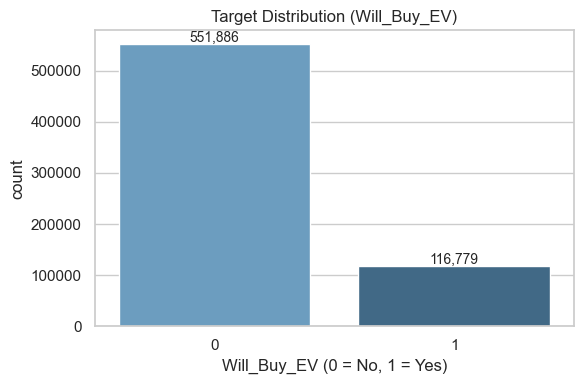

In [151]:
# Target distribution
target_counts = train_df[TARGET].value_counts().sort_index()
target_pct = (target_counts / len(train_df) * 100).round(2)
print(pd.DataFrame({'count': target_counts, 'pct': target_pct}))

base_rate = train_df[TARGET].mean()
print(f'\nbase rate P(Yes) = {base_rate:.4f}')
print('sample_submission constant:', sample_sub[TARGET].unique()[:5])

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='Blues_d', ax=ax)
ax.set_title(f'Target Distribution ({TARGET})')
ax.set_xlabel(f'{TARGET} (0 = No, 1 = Yes)'); ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

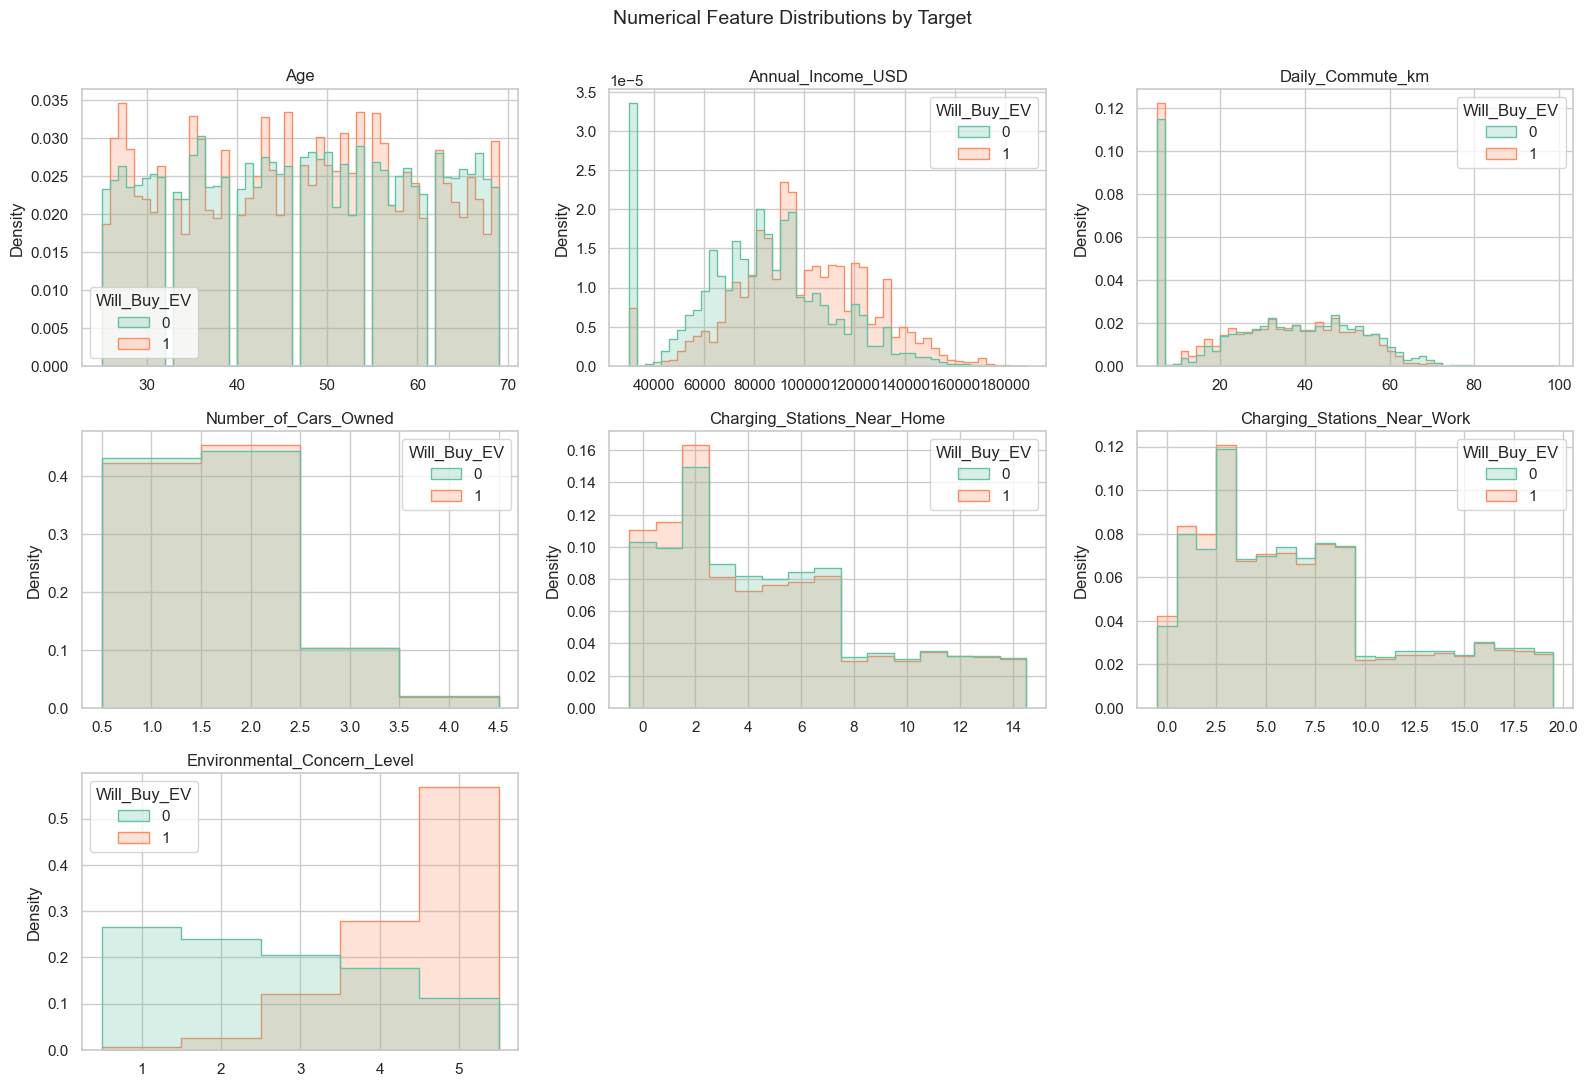

In [152]:
# Numerical feature distributions, split by target
n_cols = 3
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.6))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    discrete = train_df[col].nunique() <= 30
    sns.histplot(data=train_df, x=col, hue=TARGET, bins=None if discrete else 50, discrete=discrete,
                 ax=axes[i], palette='Set2', stat='density', common_norm=False, element='step')
    axes[i].set_title(col); axes[i].set_xlabel('')

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

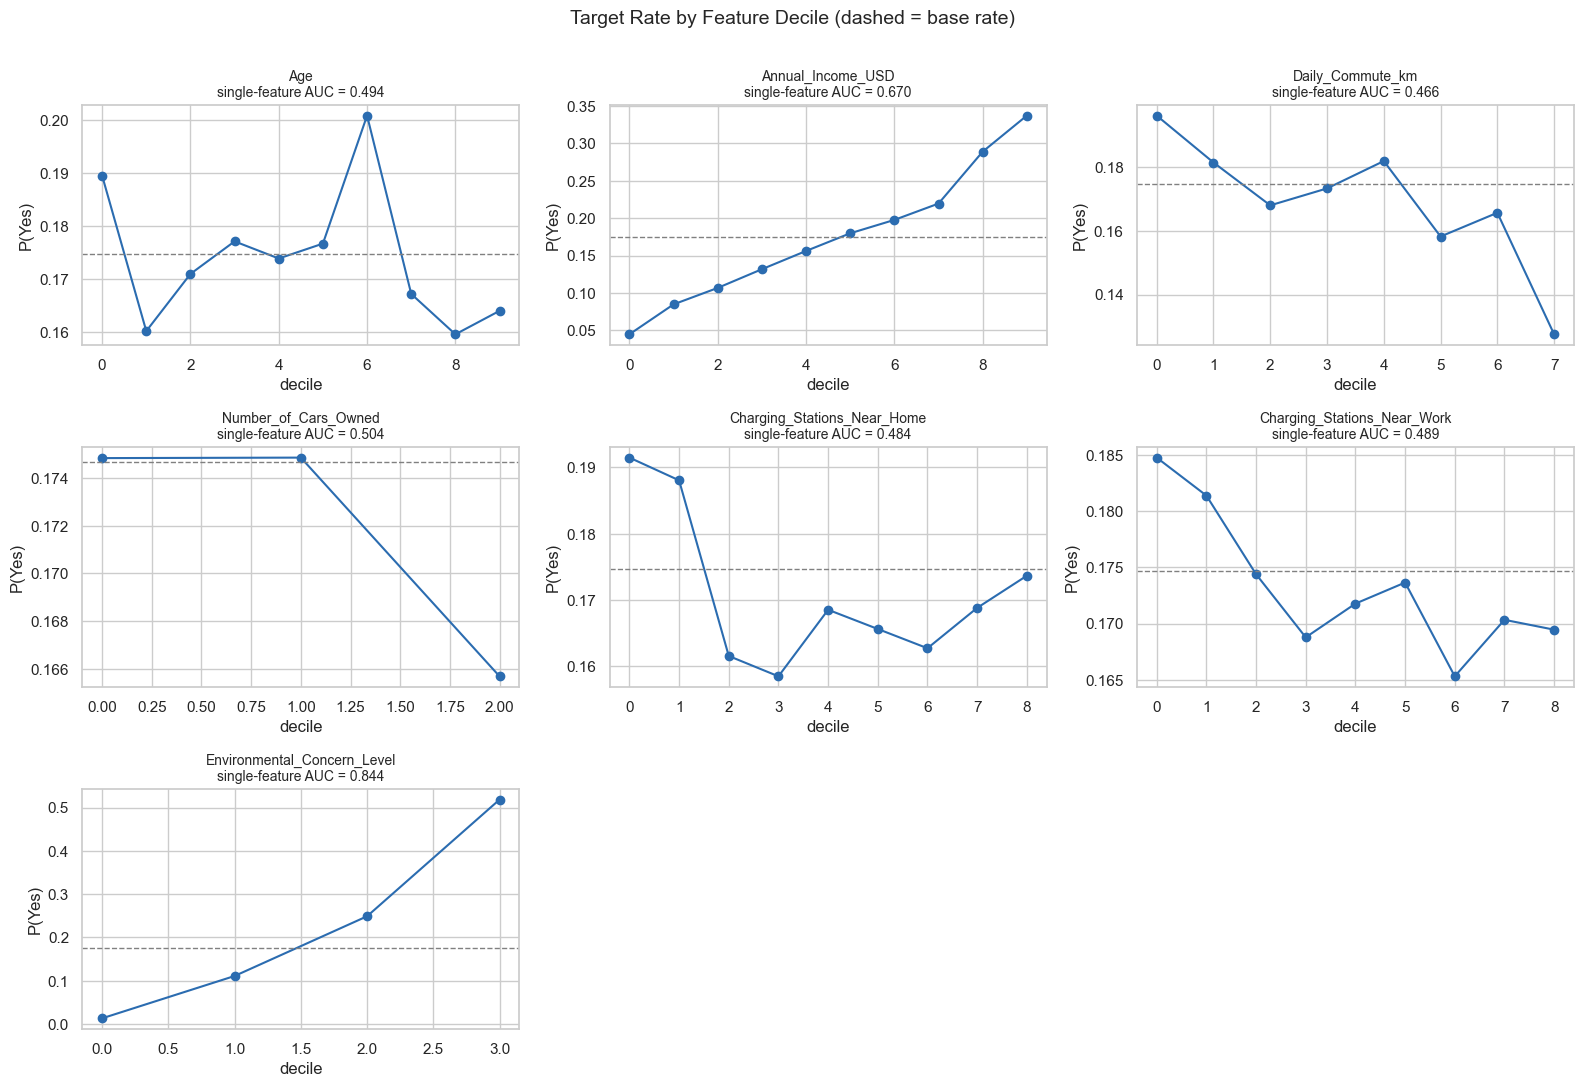

Environmental_Concern_Level    0.8435
Annual_Income_USD              0.6704
Number_of_Cars_Owned           0.5039
Age                            0.4945
Charging_Stations_Near_Work    0.4894
Charging_Stations_Near_Home    0.4841
Daily_Commute_km               0.4662
dtype: float64


In [153]:
# Target rate per feature decile -> monotonicity and signal strength.
# Single-feature AUC is printed next to each curve, but read the CURVE: a zig-zag relationship
# scores ~0.50 while being highly predictive (the lesson of S6E8).
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.6))
axes = axes.flatten()

single_auc = {}
for i, col in enumerate(NUM_COLS):
    tmp = train_df[[col, TARGET]].dropna()
    single_auc[col] = roc_auc_score(tmp[TARGET], tmp[col])

    bins = pd.qcut(tmp[col], 10, duplicates='drop')
    rate = tmp.groupby(bins, observed=True)[TARGET].mean()
    axes[i].plot(range(len(rate)), rate.values, marker='o', color='#2b6cb0')
    axes[i].axhline(base_rate, ls='--', c='grey', lw=1)
    axes[i].set_title(f'{col}\nsingle-feature AUC = {single_auc[col]:.3f}', fontsize=10)
    axes[i].set_xlabel('decile'); axes[i].set_ylabel('P(Yes)')

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Target Rate by Feature Decile (dashed = base rate)', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

print(pd.Series(single_auc).sort_values(ascending=False).round(4))

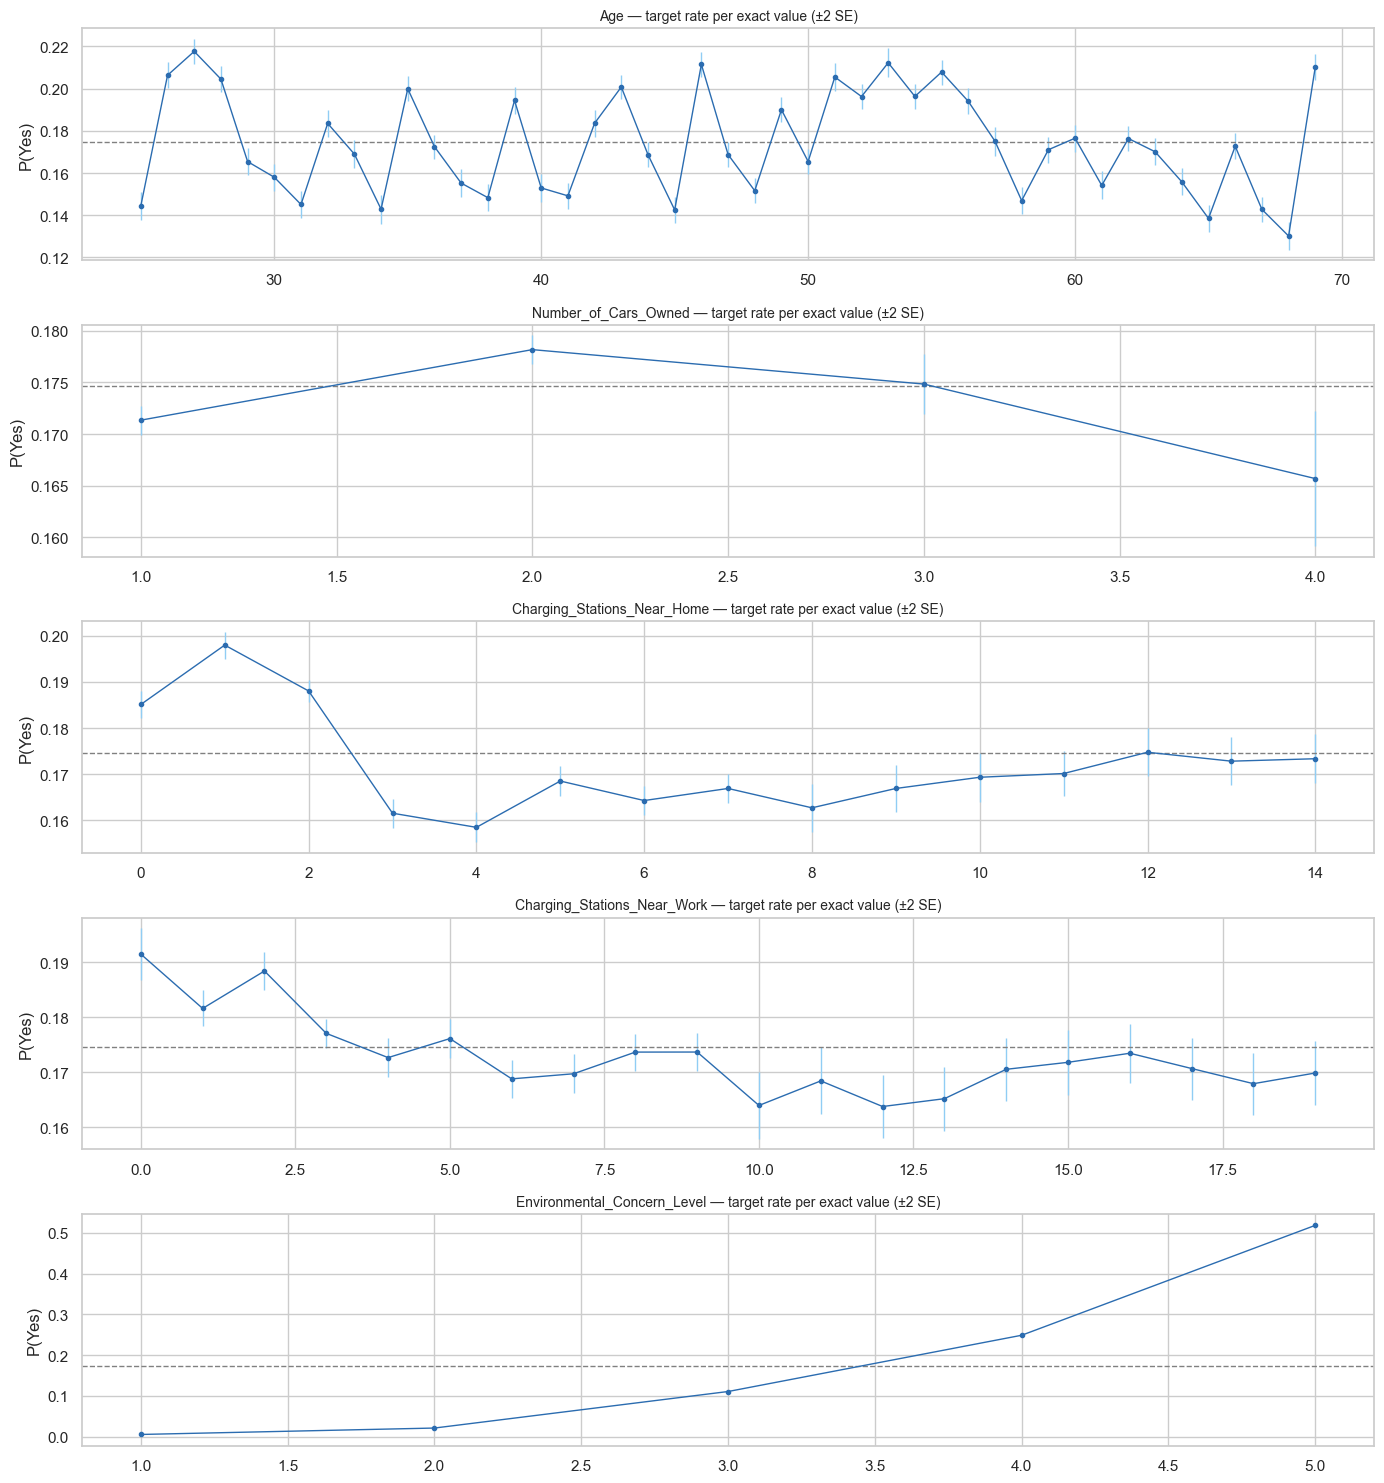

,values_with_30+_rows,dispersion_ratio
Environmental_Concern_Level,5.0,32973.57
Age,45.0,59.58
Charging_Stations_Near_Home,15.0,48.11
Number_of_Cars_Owned,4.0,13.78
Annual_Income_USD,5223.0,11.43
Charging_Stations_Near_Work,20.0,10.68
Daily_Commute_km,652.0,9.33


In [154]:
# Target rate per EXACT value, for the low-cardinality numerical columns.
# Error bars are ±2 binomial standard errors. If neighbouring values jump by many standard errors,
# the label depends on the exact value like a lookup table — that is the generator fingerprint that
# exact-value target encoding extracts.
LOW_CARD = [c for c in NUM_COLS if train_df[c].nunique() <= 60]

if LOW_CARD:
    fig, axes = plt.subplots(len(LOW_CARD), 1, figsize=(14, 3.0 * len(LOW_CARD)))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, LOW_CARD):
        g = train_df.groupby(col)[TARGET].agg(['mean', 'count'])
        se = np.sqrt(base_rate * (1 - base_rate) / g['count'])
        ax.errorbar(g.index, g['mean'], yerr=2 * se, fmt='o-', ms=3, lw=1, color='#2b6cb0', ecolor='#90cdf4')
        ax.axhline(base_rate, ls='--', c='grey', lw=1)
        ax.set_title(f'{col} — target rate per exact value (±2 SE)', fontsize=10)
        ax.set_ylabel('P(Yes)')
    plt.tight_layout(); plt.show()

# Dispersion ratio: observed variance of the per-value rates over the variance pure binomial noise
# would produce. ~1 means the per-value rates are noise around the base rate; >>1 means real signal.
disp = {}
for col in NUM_COLS:
    g = train_df.groupby(col)[TARGET].agg(['mean', 'count'])
    g = g[g['count'] >= 30]
    if len(g) < 3:
        continue
    obs = np.average((g['mean'] - base_rate) ** 2, weights=g['count'])
    exp = np.average(base_rate * (1 - base_rate) / g['count'], weights=g['count'])
    disp[col] = {'values_with_30+_rows': len(g), 'dispersion_ratio': obs / exp}
display(pd.DataFrame(disp).T.round(2).sort_values('dispersion_ratio', ascending=False))

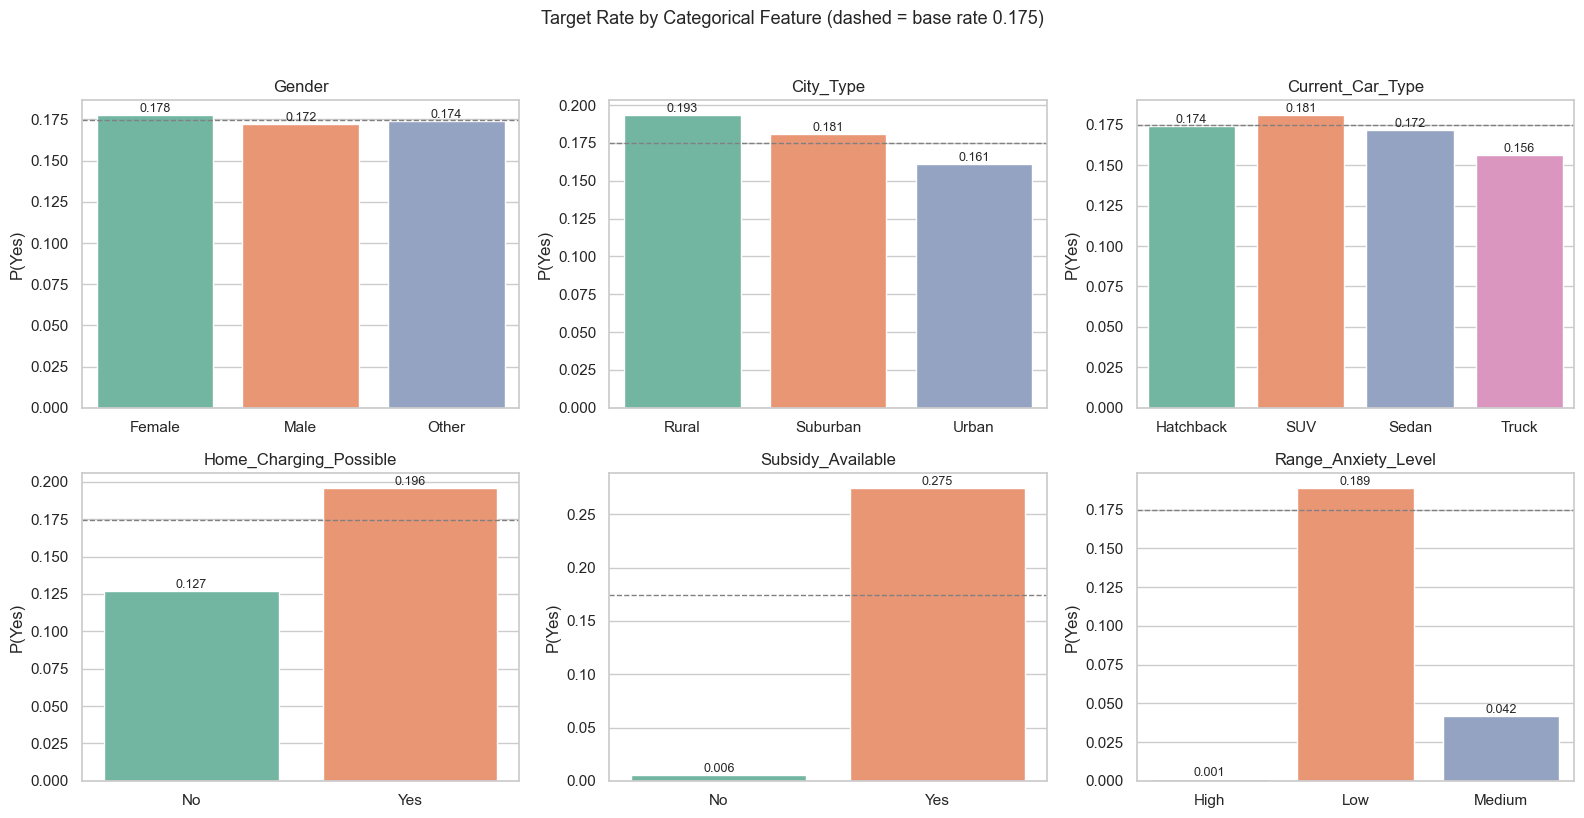

          mean   count
Gender                
Female  0.1776  295427
Male    0.1723  367954
Other   0.1737    5284 

             mean   count
City_Type                
Rural      0.1934  123983
Suburban   0.1809  255377
Urban      0.1611  289305 

                    mean   count
Current_Car_Type                
Hatchback         0.1743   79438
SUV               0.1810  246545
Sedan             0.1720  303459
Truck             0.1564   39223 

                          mean   count
Home_Charging_Possible                
No                      0.1271  205988
Yes                     0.1958  462677 

                     mean   count
Subsidy_Available                
No                 0.0058  248756
Yes                0.2747  419909 

                       mean   count
Range_Anxiety_Level                
High                 0.0014    2194
Low                  0.1890  603972
Medium               0.0417   62499 



In [155]:
# Categorical features
cat_rows = int(np.ceil(len(CAT_COLS) / 3))
fig, axes = plt.subplots(cat_rows, 3, figsize=(16, cat_rows * 4))
axes = axes.flatten()
for i, col in enumerate(CAT_COLS):
    g = train_df.groupby(col, dropna=False)[TARGET].agg(['mean', 'count'])
    sns.barplot(x=g.index.astype(str), y=g['mean'], palette='Set2', ax=axes[i])
    axes[i].axhline(base_rate, ls='--', c='grey', lw=1)
    axes[i].set_title(col); axes[i].set_ylabel('P(Yes)'); axes[i].set_xlabel('')
    for p, v in zip(axes[i].patches, g['mean']):
        axes[i].annotate(f'{v:.3f}', (p.get_x() + p.get_width() / 2, v), ha='center', va='bottom', fontsize=9)
for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Target Rate by Categorical Feature (dashed = base rate {base_rate:.3f})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

for col in CAT_COLS:
    print(train_df.groupby(col, dropna=False)[TARGET].agg(['mean', 'count']).round(4), '\n')

In [156]:
# Is missingness related to the target? (MCAR check)
rows = []
for col in NUM_COLS + CAT_COLS:
    m = train_df[col].isna()
    if m.sum() == 0:
        continue
    rows.append({
        'feature': col,
        'na_rate': round(m.mean(), 4),
        'P(y=1 | NA)': round(train_df.loc[m, TARGET].mean(), 4),
        'P(y=1 | not NA)': round(train_df.loc[~m, TARGET].mean(), 4),
    })
if rows:
    na_signal = pd.DataFrame(rows)
    na_signal['diff'] = (na_signal['P(y=1 | NA)'] - na_signal['P(y=1 | not NA)']).round(4)
    display(na_signal.sort_values('diff', key=abs, ascending=False))
else:
    print('No missing values -> nothing to check.')

No missing values -> nothing to check.


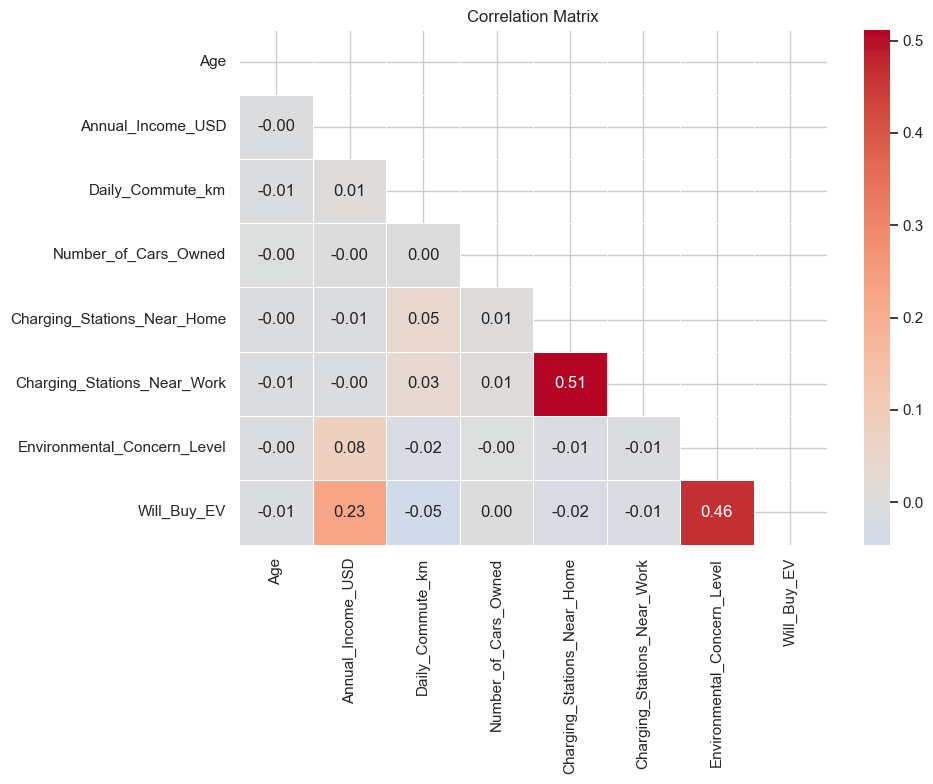

In [157]:
# Correlation matrix (numerical + target)
corr = train_df[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

In [158]:
# Train vs test drift: two-sample KS statistic per numerical column. On Playground data the two
# splits come from the same generator, so this should be ~0 everywhere. A large value would mean
# CV does not represent the test set and would change how much to trust OOF gains.
drift = pd.Series({
    c: ks_2samp(train_df[c].dropna(), test_df[c].dropna()).statistic for c in NUM_COLS
}).sort_values(ascending=False)
print('KS statistic, train vs test:')
print(drift.round(4).to_string())

KS statistic, train vs test:
Charging_Stations_Near_Work    0.0030
Age                            0.0023
Number_of_Cars_Owned           0.0017
Annual_Income_USD              0.0016
Charging_Stations_Near_Home    0.0016
Environmental_Concern_Level    0.0013
Daily_Commute_km               0.0011


**Before moving on, note down from this section:**
1. Which columns have strong monotonic signal (high single-feature AUC, smooth decile curve).
2. Which columns look useless by AUC but have a jagged per-value curve or a dispersion ratio well
   above 1 — those are where the target encoding should pay.
3. Whether missingness carries signal (if the NA/non-NA gap is tiny, it is MCAR and only a
   `n_missing` count is kept).

Section 3 then measures point 2 directly with the raw-versus-encoded AUC table.

## 3. Feature Engineering & Encodings

**1) No imputation.** LightGBM, XGBoost and CatBoost handle NaN natively. CatBoost rejects NaN in
categorical columns, so there missingness becomes its own `'Missing'` level.

**2) Hand-built features** are ones a tree cannot form on its own because they combine several
columns arithmetically: total / minimum charging-station access, income per car, commute relative to
charging access, commute × range anxiety, and a simple "EV readiness" sum. In S6E8 every hand-built
feature measured at zero once the encodings were present, so they are treated as a group and
measured in section 3b rather than trusted.

**3) Ordinal recodings.** `Range_Anxiety_Level` is ordered (Low < Medium < High) and the Yes/No
columns are binary, so numeric versions sit alongside the native categoricals.

**4) Categoricals stay model-native:** `category` dtype for LightGBM, `enable_categorical=True` for
XGBoost, `cat_features` for CatBoost.

In [159]:
ANXIETY_ORDER = {'Low': 0, 'Medium': 1, 'High': 2}
YES_NO = {'No': 0, 'Yes': 1}

_unmapped = set(train_df['Range_Anxiety_Level'].dropna().unique()) - set(ANXIETY_ORDER)
if _unmapped:
    print(f'WARNING: Range_Anxiety_Level levels not in ANXIETY_ORDER: {_unmapped} -> they become NaN in anxiety_ord')


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    inc = df['Annual_Income_USD']
    cars = df['Number_of_Cars_Owned']
    commute = df['Daily_Commute_km']
    home = df['Charging_Stations_Near_Home']
    work = df['Charging_Stations_Near_Work']

    # --- ordinal / binary recodings of the categoricals ---
    df['anxiety_ord'] = df['Range_Anxiety_Level'].map(ANXIETY_ORDER).astype('float64')
    df['home_charge_yes'] = df['Home_Charging_Possible'].map(YES_NO).astype('float64')
    df['subsidy_yes'] = df['Subsidy_Available'].map(YES_NO).astype('float64')

    # --- charging infrastructure ---
    df['stations_total'] = home + work
    df['stations_min'] = np.fmin(home, work)
    df['stations_diff'] = work - home

    # --- economics ---
    df['log_income'] = np.log1p(inc)
    df['income_per_car'] = inc / (cars + 1)

    # --- range pressure: long commute with little charging access / high anxiety ---
    df['commute_per_station'] = commute / (df['stations_total'] + 1)
    df['commute_x_anxiety'] = commute * df['anxiety_ord']

    # --- a crude "readiness" score summing the enabling factors ---
    df['ev_readiness'] = (df['home_charge_yes'] + df['subsidy_yes']
                          - df['anxiety_ord'] + df['Environmental_Concern_Level'] / 5)

    # --- missingness density ---
    df['n_missing'] = df[NUM_COLS + CAT_COLS].isna().sum(axis=1).astype('int8')

    return df


ENG_COLS = [
    'anxiety_ord', 'home_charge_yes', 'subsidy_yes',
    'stations_total', 'stations_min', 'stations_diff',
    'log_income', 'income_per_car',
    'commute_per_station', 'commute_x_anxiety', 'ev_readiness',
    'n_missing',
]

train_fe = add_features(train_df)
test_fe = add_features(test_df)

# One shared category list per column, so train and test codes line up for LightGBM / XGBoost.
for c in CAT_COLS:
    cats = sorted(set(train_fe[c].dropna()) | set(test_fe[c].dropna()))
    train_fe[c] = pd.Categorical(train_fe[c], categories=cats)
    test_fe[c] = pd.Categorical(test_fe[c], categories=cats)

print(f'{len(NUM_COLS)} num + {len(CAT_COLS)} cat + {len(ENG_COLS)} engineered')
train_fe[ENG_COLS].describe().T.round(3)

7 num + 6 cat + 12 engineered


,count,mean,std,min,25%,50%,75%,max
anxiety_ord,668665.0,0.100,0.311,0.000,0.000,0.000,0.000,2.000
home_charge_yes,668665.0,0.692,0.462,0.000,0.000,1.000,1.000,1.000
subsidy_yes,668665.0,0.628,0.483,0.000,0.000,1.000,1.000,1.000
stations_total,668665.0,12.137,7.946,0.000,5.000,11.000,18.000,33.000
stations_min,668665.0,4.145,3.467,0.000,1.000,3.000,6.000,14.000
stations_diff,668665.0,2.216,4.637,-12.000,-1.000,2.000,5.000,18.000
log_income,668665.0,11.278,0.400,10.309,11.118,11.349,11.540,12.147
income_per_car,668665.0,33385.359,14232.629,6000.000,23238.500,31593.667,42384.000,94274.500
commute_per_station,668665.0,4.189,5.643,0.147,1.250,2.500,4.875,96.000
commute_x_anxiety,668665.0,4.326,14.902,0.000,0.000,0.000,0.000,197.400


### Encodings

Three families, all keyed on the **exact value** of a column:

| Family | What it is | Leakage handling |
|---|---|---|
| `*_te` | `P(Yes \| exact value)`, smoothed toward the prior | **nested**, rebuilt inside every CV fold |
| `*_freq` | how often the exact value occurs in train + test | none needed — no target involved |
| `*_orig_te` | `P(Yes \| exact value)` measured on the *original* dataset | none needed — a different dataset |

Plus one categorical interaction key, `cat_combo` — all six categoricals concatenated — which is
target-encoded the same way. Six low-cardinality columns give at most a few hundred combinations,
so every cell has thousands of rows behind it.

**Why nested.** In S6E8 the encoding was built once, out-of-fold on the same folds the models used.
That leaves a subtle leak: a training row in fold *j* carries an encoding fitted on a table that
includes fold *k*'s targets, and the model then validates on fold *k*. Here the encoding for outer
fold *k* is fitted on fold *k*'s training rows only — inner out-of-fold for those rows, the full
training-part table for the validation rows and for test. Validation targets never touch a feature.
The encodings are cheap (integer codes + `bincount`), so this costs seconds, and each fold's
result is cached and reused by every model.

In [160]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(train_fe, y))
n_tr = len(train_fe)

# Smoothing pulls rare values toward the prior: (sum + k * prior) / (count + k).
TE_SMOOTH = 20
TE_SMOOTH_BY_KEY = {}          # per-key override, used by the round 7 smoothing variants
TE_INNER_SPLITS = 5
# Only encode columns whose values repeat enough to estimate a rate. Near-continuous columns
# (a handful of rows per value) would get encodings that are almost all prior plus noise.
TE_MIN_ROWS_PER_VALUE = 20

TE_SRC = [c for c in NUM_COLS if support.loc[c, 'rows_per_value'] >= TE_MIN_ROWS_PER_VALUE]
TE_SRC_ALL = TE_SRC + ['cat_combo']
print('target-encoded columns :', TE_SRC)
print('skipped (low support)  :', [c for c in NUM_COLS if c not in TE_SRC])


def make_key(df, name):
    """String key for the exact value of a column (or the all-categoricals combination)."""
    if name == 'cat_combo':
        k = df[CAT_COLS[0]].astype('string').fillna('__NA__')
        for c in CAT_COLS[1:]:
            k = k + '|' + df[c].astype('string').fillna('__NA__')
        return k
    s = df[name]
    if name in NUM_COLS:
        # normalise to float so 5 and 5.0 map to the same key across files
        s = pd.to_numeric(s, errors='coerce').astype('float64').round(6)
    return s.astype('string').fillna('__NA__')


# Integer codes over train + test, so a fold's table is a single bincount.
CODES = {}
for name in TE_SRC_ALL:
    k = pd.concat([make_key(train_fe, name), make_key(test_fe, name)], ignore_index=True)
    codes, uniq = pd.factorize(k)
    CODES[name] = (codes[:n_tr], codes[n_tr:], len(uniq))

TE_ALL = [f'{name}_te' for name in TE_SRC_ALL]


def te_fit(codes, yv, n_codes, prior, smooth=None):
    """Smoothed P(y=1 | code). A code never seen in `codes` gets exactly the prior."""
    k = TE_SMOOTH if smooth is None else smooth
    s = np.bincount(codes, weights=yv, minlength=n_codes)
    n = np.bincount(codes, minlength=n_codes)
    return (s + k * prior) / (n + k)


def target_encode(tr_idx, va_idx):
    """Nested target encoding for one outer fold.

    Training rows get an inner out-of-fold encoding, validation and test rows get the table
    fitted on all of tr_idx. No target outside tr_idx is ever read.
    """
    y_tr = y[tr_idx].astype('float64')
    inner = list(StratifiedKFold(TE_INNER_SPLITS, shuffle=True, random_state=SEED)
                 .split(np.zeros(len(tr_idx)), y_tr))
    out_tr, out_va, out_te = {}, {}, {}
    for name, (c_train, c_test, n_codes) in CODES.items():
        c_fit = c_train[tr_idx]
        sm = TE_SMOOTH_BY_KEY.get(name, TE_SMOOTH)
        enc_tr = np.empty(len(tr_idx))
        for a, b in inner:
            enc_tr[b] = te_fit(c_fit[a], y_tr[a], n_codes, y_tr[a].mean(), sm)[c_fit[b]]
        full = te_fit(c_fit, y_tr, n_codes, y_tr.mean(), sm)
        out_tr[f'{name}_te'] = enc_tr.astype('float32')
        out_va[f'{name}_te'] = full[c_train[va_idx]].astype('float32')
        out_te[f'{name}_te'] = full[c_test].astype('float32')
    return pd.DataFrame(out_tr), pd.DataFrame(out_va), pd.DataFrame(out_te)


# --- frequency encoding: no target, counts over train + test ---
FREQ_COLS = []
for col in NUM_COLS:
    k_tr, k_te = make_key(train_fe, col), make_key(test_fe, col)
    counts = pd.concat([k_tr, k_te]).value_counts()
    enc = f'{col}_freq'
    train_fe[enc] = k_tr.map(counts).astype('float64').values
    test_fe[enc] = k_te.map(counts).astype('float64').values
    FREQ_COLS.append(enc)

# --- original-dataset target encoding (skipped when the file is absent) ---
HAVE_ORIG = os.path.exists(ORIG_PATH)
ORIG_SMOOTH = 5
ORIG_TE_COLS = []
ORIG_LITE_COLS = []
if HAVE_ORIG:
    orig_df = pd.read_csv(ORIG_PATH)
    missing = set(NUM_COLS + CAT_COLS + [TARGET]) - set(orig_df.columns)
    assert not missing, f'original dataset lacks {missing} — rename its columns to match the competition'
    # pandas 3 reads text as the 'str' dtype, not object, so test for 'not numeric' instead
    if not pd.api.types.is_numeric_dtype(orig_df[TARGET]):
        orig_df[TARGET] = orig_df[TARGET].map(TARGET_MAP)
    orig_df = orig_df.dropna(subset=[TARGET])
    y_orig = orig_df[TARGET].astype('float64').values
    orig_prior = y_orig.mean()
    print(f'\noriginal dataset: {len(orig_df):,} rows, P(Yes) = {orig_prior:.4f}')

    for name in NUM_COLS + ['cat_combo']:
        g = (pd.DataFrame({'k': make_key(orig_df, name).values, 'y': y_orig})
             .groupby('k')['y'].agg(['sum', 'count']))
        tbl = (g['sum'] + ORIG_SMOOTH * orig_prior) / (g['count'] + ORIG_SMOOTH)
        enc = f'{name}_orig_te'
        # NaN where the value never occurs in the original — the trees can use that as its own signal
        train_fe[enc] = make_key(train_fe, name).map(tbl).astype('float64').values
        test_fe[enc] = make_key(test_fe, name).map(tbl).astype('float64').values
        ORIG_TE_COLS.append(enc)
        print(f'  {enc:<40} train coverage {train_fe[enc].notna().mean():6.1%}   '
              f'test coverage {test_fe[enc].notna().mean():6.1%}')

    # Round 2: the full orig group measured -0.000104 (t = -2.78, 0/5) -> 'hurts'. The original has
    # only 10k rows, so for near-continuous columns (income: ~1 row per value) its per-value rate is
    # essentially a single label shrunk to the prior — a noisy feature. orig_lite keeps only the
    # encodings whose key has real support in the original, to test whether the loss came from those
    # noisy columns or from the original's rates themselves.
    ORIG_MIN_ROWS_PER_VALUE = 20
    orig_support = {name: len(orig_df) / max(make_key(orig_df, name).nunique(), 1)
                    for name in NUM_COLS + ['cat_combo']}
    ORIG_LITE_COLS = [f'{n}_orig_te' for n, s in orig_support.items() if s >= ORIG_MIN_ROWS_PER_VALUE]
    print('\norig rows per value:', {k: round(v, 1) for k, v in orig_support.items()})
    print('orig_lite columns  :', ORIG_LITE_COLS)
else:
    print(f'\n{ORIG_PATH} not found -> original-dataset encodings skipped')

target-encoded columns : ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
skipped (low support)  : []

original dataset: 10,000 rows, P(Yes) = 0.1750
  Age_orig_te                              train coverage 100.0%   test coverage 100.0%
  Annual_Income_USD_orig_te                train coverage  97.9%   test coverage  97.9%
  Daily_Commute_km_orig_te                 train coverage 100.0%   test coverage 100.0%
  Number_of_Cars_Owned_orig_te             train coverage 100.0%   test coverage 100.0%
  Charging_Stations_Near_Home_orig_te      train coverage 100.0%   test coverage 100.0%
  Charging_Stations_Near_Work_orig_te      train coverage 100.0%   test coverage 100.0%
  Environmental_Concern_Level_orig_te      train coverage 100.0%   test coverage 100.0%
  cat_combo_orig_te                        train coverage  99.9%   test coverage  99.9%

orig rows per value: {'Age':

In [161]:
# Diagnostic: how much does exact-value encoding add over the raw column, per column?
# Plain out-of-fold TE on FOLDS (the nested version is for training; this is only a measurement).
rows = []
for name in TE_SRC_ALL:
    c_train, _, n_codes = CODES[name]
    enc = np.empty(n_tr)
    for tr_idx, va_idx in FOLDS:
        enc[va_idx] = te_fit(c_train[tr_idx], y[tr_idx].astype('float64'), n_codes, y[tr_idx].mean())[c_train[va_idx]]
    raw_auc = np.nan
    if name in NUM_COLS:
        m = train_fe[name].notna().values
        raw_auc = roc_auc_score(y[m], train_fe[name].values[m])
        raw_auc = max(raw_auc, 1 - raw_auc)        # direction-free, so it is comparable to TE
    rows.append({'feature': name, 'raw_auc': raw_auc, 'te_auc': roc_auc_score(y, enc)})

te_gain = pd.DataFrame(rows)
te_gain['delta'] = te_gain['te_auc'] - te_gain['raw_auc']
display(te_gain.round(4).sort_values('delta', ascending=False))

,feature,raw_auc,te_auc,delta
1,Annual_Income_USD,0.6704,0.7119,0.0415
0,Age,0.5055,0.5467,0.0412
2,Daily_Commute_km,0.5338,0.5513,0.0175
4,Charging_Stations_Near_Home,0.5159,0.5230,0.0071
3,Number_of_Cars_Owned,0.5039,0.5053,0.0014
5,Charging_Stations_Near_Work,0.5106,0.5111,0.0004
6,Environmental_Concern_Level,0.8435,0.8428,-0.0007
7,cat_combo,NaN,0.7549,NaN


**Reading the table.** A large positive `delta` means the column carries non-monotonic,
per-value signal that the raw column hides — in S6E8 that was +0.19 to +0.26 on the columns that
looked worthless. A negative delta is normal for smooth, strongly monotonic columns: the encoding
loses the ordering. That is **not** a reason to drop the encoding — the raw column supplies the
trend, the encoding supplies each value's deviation from it. (Dropping three such encodings cost
0.0022 on the S6E8 leaderboard.)

In [162]:
# --- Model-ready frames ---
GROUPS = {
    'raw':   NUM_COLS + CAT_COLS,
    'eng':   ENG_COLS,
    'te':    [f'{c}_te' for c in TE_SRC],
    'freq':  FREQ_COLS,
    'combo': ['cat_combo_te'],
    'orig':  ORIG_TE_COLS,
    'orig_lite': ORIG_LITE_COLS,
}

STATIC_COLS = NUM_COLS + CAT_COLS + ENG_COLS + FREQ_COLS + ORIG_TE_COLS
X_static = train_fe[STATIC_COLS]
X_test_static = test_fe[STATIC_COLS]


def to_catboost(df):
    df = df.copy()
    for c in CAT_COLS:
        df[c] = df[c].astype('string').fillna('Missing').astype(str)
    return df


X_static_cb = to_catboost(X_static)
X_test_static_cb = to_catboost(X_test_static)

ENC_CACHE = {}


def get_fold(fold, cols, catboost=False, with_test=True):
    """Feature frames for one outer fold: static columns + that fold's nested target encodings."""
    tr_idx, va_idx = FOLDS[fold]
    base, base_te = (X_static_cb, X_test_static_cb) if catboost else (X_static, X_test_static)

    static = [c for c in cols if c not in TE_ALL]
    X_tr = base.iloc[tr_idx][static].reset_index(drop=True)
    X_va = base.iloc[va_idx][static].reset_index(drop=True)
    X_te = base_te[static].reset_index(drop=True) if with_test else None

    te_cols = [c for c in cols if c in TE_ALL]
    if te_cols:
        if fold not in ENC_CACHE:
            ENC_CACHE[fold] = target_encode(tr_idx, va_idx)
        e_tr, e_va, e_te = ENC_CACHE[fold]
        X_tr = pd.concat([X_tr, e_tr[te_cols]], axis=1)
        X_va = pd.concat([X_va, e_va[te_cols]], axis=1)
        if with_test:
            X_te = pd.concat([X_te, e_te[te_cols]], axis=1)

    return X_tr[cols], X_va[cols], (X_te[cols] if with_test else None), tr_idx, va_idx


for g, cols in GROUPS.items():
    print(f'{g:<6} {len(cols):>3} columns')

raw     13 columns
eng     12 columns
te       7 columns
freq     7 columns
combo    1 columns
orig     8 columns
orig_lite   6 columns


## 3b. Feature-group ablation

Every variant is one LightGBM run over the **same folds** (the first `ABL_FOLDS` of the 10), so the
difficulty of each fold cancels out when two variants are compared. Two kinds of variant:

- `- group` — the candidate set with one group removed. A clearly **negative** delta means the group
  is doing work.
- `+ group` — an optional group added. It is adopted only if it clears the bar.

**The bar** (from S6E8): wins on every fold, paired `|t| ≥ 2.5`, and a paired row bootstrap puts
≥95% of resamples on the same side. Groups in the candidate set are **kept** unless removing them
clears the bar in the positive direction — moving a known-good configuration on a noise-level
difference is what caused the S6E8 regression.

In [163]:
%%time
# Decided in rounds 1-2 (results below / in MODELING_SUMMARY.md). Set True to screen a new group.
RUN_ABLATION = False
ABL_FOLDS = 5
N_BOOT = 100

CANDIDATE = ['raw', 'eng', 'te', 'freq']
# Round 2 result (vs baseline 0.945089):
#   + combo   -0.000041   t = -1.11   1/5   boot 0.17   noise (skip)
#   + orig    -0.000104   t = -2.78   0/5   boot 0.00   HURTS
#   + orig_lite -0.000114 t = -6.28   0/5   boot 0.00   HURTS -> original dataset closed
OPTIONAL = ['combo'] + (['orig', 'orig_lite'] if HAVE_ORIG else [])

abl_params = dict(
    objective='binary', n_estimators=4000, learning_rate=0.08,
    num_leaves=64, min_child_samples=60, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1,
)


def cols_of(groups):
    return [c for g in groups for c in GROUPS[g]]


def run_variant(groups):
    cols = cols_of(groups)
    oof = np.full(n_tr, np.nan)
    aucs = []
    for f in range(ABL_FOLDS):
        X_tr, X_va, _, tr_idx, va_idx = get_fold(f, cols, with_test=False)
        m = lgb.LGBMClassifier(**abl_params)
        m.fit(X_tr, y[tr_idx], eval_set=[(X_va, y[va_idx])], eval_metric='auc',
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va_idx] = m.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y[va_idx], oof[va_idx]))
    return oof, np.array(aucs)


if RUN_ABLATION:
    variants = {'baseline': CANDIDATE}
    for g in CANDIDATE:
        if g != 'raw':
            variants[f'- {g}'] = [x for x in CANDIDATE if x != g]
    for g in OPTIONAL:
        variants[f'+ {g}'] = CANDIDATE + [g]

    results = {}
    for name, groups in variants.items():
        results[name] = run_variant(groups)
        print(f'{name:<12} mean AUC {results[name][1].mean():.6f}   folds {np.round(results[name][1], 6)}')

    base_oof, base_aucs = results['baseline']
    rows_idx = np.where(~np.isnan(base_oof))[0]
    rng = np.random.default_rng(SEED)
    boots = [rng.choice(rows_idx, len(rows_idx)) for _ in range(N_BOOT)]

    table = []
    for name, (oof_v, aucs_v) in results.items():
        if name == 'baseline':
            continue
        d = aucs_v - base_aucs
        t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if d.std(ddof=1) > 0 else np.nan
        bd = np.array([roc_auc_score(y[s], oof_v[s]) - roc_auc_score(y[s], base_oof[s]) for s in boots])
        wins = int((d > 0).sum())
        passes_pos = wins == len(d) and t >= 2.5 and (bd > 0).mean() >= 0.95
        passes_neg = wins == 0 and t <= -2.5 and (bd < 0).mean() >= 0.95
        if name.startswith('-'):
            verdict = 'group HELPS (keep)' if passes_neg else ('group HURTS (drop?)' if passes_pos else 'noise (keep)')
        else:
            verdict = 'ADOPT' if passes_pos else ('hurts' if passes_neg else 'noise (skip)')
        table.append({'variant': name, 'mean_delta': d.mean(), 't': t,
                      'folds_won': f'{wins}/{len(d)}', 'boot_P(>0)': (bd > 0).mean(), 'verdict': verdict})

    print(f'\nbaseline {CANDIDATE}: {base_aucs.mean():.6f}')
    display(pd.DataFrame(table).round(6))
else:
    print('ablation skipped')

ablation skipped
CPU times: user 65 μs, sys: 68 μs, total: 133 μs
Wall time: 291 μs


In [164]:
# --- Feature set for section 4. Set these from the ablation table above, not before. ---
# The candidate groups stay in unless '- group' shows them clearly HURTING.
USE_GROUPS = ['raw', 'eng', 'te', 'freq']
ADOPT_COMBO = False
ADOPT_ORIG = False          # round 2: hurts (-0.000104, 0/5 folds)
ADOPT_ORIG_LITE = False     # round 2: hurts (-0.000114, t = -6.28, 0/5 folds)

if ADOPT_COMBO:
    USE_GROUPS.append('combo')
if ADOPT_ORIG and HAVE_ORIG:
    USE_GROUPS.append('orig')
if ADOPT_ORIG_LITE and HAVE_ORIG:
    USE_GROUPS.append('orig_lite')

FEATURES = cols_of(USE_GROUPS)
CAT_IDX = [FEATURES.index(c) for c in CAT_COLS if c in FEATURES]
print(f'groups: {USE_GROUPS}')
print(f'{len(FEATURES)} features')

groups: ['raw', 'eng', 'te', 'freq']
39 features


## 3c. Hyperparameter sweep

The models stop early at ~500 iterations (lr 0.03) and the label looks rule-based with noise, so tree
**capacity** is the untested axis: fewer / more leaves, and a larger minimum leaf size.

Same harness as 3b — one LightGBM per setting over the same `ABL_FOLDS` folds, on the final `FEATURES`,
compared **paired** against the current setting (`num_leaves=64, min_child_samples=60`) with the same
bar (all folds won, `t ≥ 2.5`, bootstrap ≥ 95%). The sweep runs at lr 0.08 for speed; the ranking of
capacity settings transfers to lr 0.03, the absolute numbers do not.

**Carrying a result to XGBoost / CatBoost.** Only LightGBM is swept. The adopted setting is translated:
`max_depth = floor(log2(num_leaves + 1)) + 1` (64 leaves ↔ depth 7, today's value) and
`min_child_weight = min_child_samples / 3` (60 ↔ 20, today's value); CatBoost gets the same depth. That
translation is a heuristic, so section 4 prints every model's OOF against its round 1 value — if XGBoost
or CatBoost gets worse, revert that model alone.

In [165]:
%%time
# Round 4: 7 leaves not established (+0.000053, t = 1.74, 4/5) -> nl15_mcs300 stays. Axis closed.
RUN_TUNE = False
TUNE_FOLDS = ABL_FOLDS

# Round 3 sweep, baseline nl64_mcs60 (0.945089) — full table in MODELING_SUMMARY.md §5b:
#   nl15_mcs300 +0.000181 t=5.20 5/5 ADOPT (submitted, LB 0.94582) | nl15_mcs1000 +0.000159 | nl15_mcs60 +0.000155
#   nl31_mcs300 +0.000145 | nl31_mcs60 +0.000097 | col0.5 +0.000082 4/5 | nl64_* ~0 | nl127_* -0.0002..-0.0003
#
# Round 4: the winner sat on the edge of the grid (15 = fewest leaves tried), so 7 leaves is checked,
# plus col0.5 on top of the small trees. The baseline is now the SUBMITTED setting, nl15_mcs300 —
# the ablation baseline stays pinned to what is actually on the leaderboard.
TUNE_BASE = 'nl15_mcs300'
TUNE_GRID = {}
for nl in (7, 15, 31, 64, 127):
    for mcs in (60, 300, 1000):
        TUNE_GRID[f'nl{nl}_mcs{mcs}'] = dict(num_leaves=nl, min_child_samples=mcs)
TUNE_GRID['nl64_mcs60_col0.5'] = dict(num_leaves=64, min_child_samples=60, colsample_bytree=0.5)
TUNE_GRID['nl64_mcs60_l2_10'] = dict(num_leaves=64, min_child_samples=60, reg_lambda=10.0)
TUNE_GRID['nl15_mcs300_col0.5'] = dict(num_leaves=15, min_child_samples=300, colsample_bytree=0.5)

# Which settings to run this time (the baseline is always included). None = the whole grid.
TUNE_RUN = ['nl7_mcs60', 'nl7_mcs300', 'nl7_mcs1000', 'nl15_mcs300_col0.5']


def run_params(overrides, cols):
    params = {**abl_params, **overrides}
    oof = np.full(n_tr, np.nan)
    aucs, iters = [], []
    for f in range(TUNE_FOLDS):
        X_tr, X_va, _, tr_idx, va_idx = get_fold(f, cols, with_test=False)
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y[tr_idx], eval_set=[(X_va, y[va_idx])], eval_metric='auc',
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va_idx] = m.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y[va_idx], oof[va_idx]))
        iters.append(m.best_iteration_)
    return oof, np.array(aucs), int(np.mean(iters))


if RUN_TUNE:
    tune_res = {}
    _to_run = list(TUNE_GRID) if TUNE_RUN is None else [TUNE_BASE] + [n for n in TUNE_RUN if n != TUNE_BASE]
    for name in _to_run:
        tune_res[name] = run_params(TUNE_GRID[name], FEATURES)
        print(f'{name:<20} mean AUC {tune_res[name][1].mean():.6f}   mean iter {tune_res[name][2]:>5}')

    base_oof, base_aucs, _ = tune_res[TUNE_BASE]
    rows_idx = np.where(~np.isnan(base_oof))[0]
    rng = np.random.default_rng(SEED)
    boots = [rng.choice(rows_idx, len(rows_idx)) for _ in range(N_BOOT)]

    table = []
    for name, (oof_v, aucs_v, it) in tune_res.items():
        if name == TUNE_BASE:
            continue
        d = aucs_v - base_aucs
        t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if d.std(ddof=1) > 0 else np.nan
        bd = np.array([roc_auc_score(y[s], oof_v[s]) - roc_auc_score(y[s], base_oof[s]) for s in boots])
        wins = int((d > 0).sum())
        passes = wins == len(d) and t >= 2.5 and (bd > 0).mean() >= 0.95
        table.append({'setting': name, 'mean_delta': d.mean(), 't': t, 'folds_won': f'{wins}/{len(d)}',
                      'boot_P(>0)': (bd > 0).mean(), 'mean_iter': it, 'verdict': 'ADOPT' if passes else '-'})

    tune_table = pd.DataFrame(table).sort_values('mean_delta', ascending=False)
    print(f'\nbaseline {TUNE_BASE}: {base_aucs.mean():.6f}')
    display(tune_table.round(6))
    passing = tune_table[tune_table['verdict'] == 'ADOPT']
    print('best setting clearing the bar:', passing.iloc[0]['setting'] if len(passing) else 'none -> keep TUNE_ADOPT = None')
else:
    print('sweep skipped')

sweep skipped
CPU times: user 84 μs, sys: 57 μs, total: 141 μs
Wall time: 349 μs


In [166]:
# --- Capacity setting for section 4. Set from the sweep table above, not before. ---
# None keeps every model exactly as in round 1.
TUNE_ADOPT = 'nl15_mcs300'               # e.g. 'nl31_mcs300' — must be a TUNE_GRID key that shows ADOPT

TUNED = dict(TUNE_GRID[TUNE_ADOPT]) if TUNE_ADOPT else {}
if TUNED:
    _nl = TUNED.get('num_leaves', 64)
    _mcs = TUNED.get('min_child_samples', 60)
    XGB_TUNED = dict(max_depth=int(np.log2(_nl + 1)) + 1, min_child_weight=_mcs / 3,
                     **{k: v for k, v in TUNED.items() if k in ('colsample_bytree', 'reg_lambda')})
    CB_TUNED = dict(depth=XGB_TUNED['max_depth'])
else:
    XGB_TUNED, CB_TUNED = {}, {}
print('LightGBM overrides:', TUNED)
print('XGBoost  overrides:', XGB_TUNED)
print('CatBoost overrides:', CB_TUNED)

LightGBM overrides: {'num_leaves': 15, 'min_child_samples': 300}
XGBoost  overrides: {'max_depth': 5, 'min_child_weight': 100.0}
CatBoost overrides: {'depth': 5}


## 3d. Round 6 — ideas from an outside review

A review of this notebook suggested several directions. The ones that are cheap and genuinely untested
are measured here; the rest were set aside with reasons (heavier tabular nets, focal loss, pseudo-labelling
— see MODELING_SUMMARY.md).

1. **Exact-match diagnostics** — are there full-row duplicates inside train, train rows that also occur in
   test, or rows identical to an original row? If so, do their labels agree far above chance? A lookup
   only pays if the answer is yes *and* it beats the model on those same rows.
2. **Candidate features**, each screened as one ablation variant:
   - `row` — nested target encoding of the full 13-column row (captures duplicates and train/test overlap)
   - `pair_csa`, `pair_inc_anx` — nested TE of concern × subsidy × anxiety, and income × anxiety
   - `orig_model` — a LightGBM trained **on the original dataset only**, applied to the competition rows
   - `orig_tree` — a depth-4 decision tree fitted on the original (its rules are printed)
   - `orig_row` — the original label of an identical original row, when one exists
   - `in_orig` — whether the income value exists in the original at all
3. The ablation baseline is pinned to the **submitted** setting (15 leaves, `min_child_samples=300`), not
   to the 64-leaf `abl_params` that 3b used.

In [167]:
# --- 3d-1. Exact-match diagnostics ------------------------------------------------------------
KEY_COLS = NUM_COLS + CAT_COLS


def combo_key(df, cols):
    k = make_key(df, cols[0])
    for c in cols[1:]:
        k = k + '|' + make_key(df, c)
    return k.reset_index(drop=True)


key_tr, key_te = combo_key(train_fe, KEY_COLS), combo_key(test_fe, KEY_COLS)

# Reference: round 3 LightGBM OOF on the same rows, so a lookup is judged against the model.
_ref_file = '../preds/lgb.npz'
ref_oof = np.load(_ref_file)['oof'] if os.path.exists(_ref_file) else None


def safe_auc(yv, pv):
    return roc_auc_score(yv, pv) if len(yv) and yv.min() != yv.max() else np.nan


def ref_auc(mask):
    return safe_auc(y[mask], ref_oof[mask]) if ref_oof is not None else np.nan


# 1) full-row duplicates inside train
# pandas 3: .map() on a string Series returns an Arrow-backed array -> convert to numpy explicitly
cnt = key_tr.map(key_tr.value_counts()).to_numpy(dtype='int64')
dup = cnt > 1
print(f'train rows whose full 13-column row occurs more than once in train: {dup.sum():,} ({dup.mean():.3%})')
if dup.sum():
    g = pd.DataFrame({'k': key_tr.values, 'y': y}).groupby('k')['y'].agg(['sum', 'count'])
    s_ = key_tr.map(g['sum']).to_numpy(dtype='float64')
    n_ = key_tr.map(g['count']).to_numpy(dtype='float64')
    loo = (s_ - y) / np.maximum(n_ - 1, 1)          # label mean of the OTHER rows in the group
    print(f'  leave-one-out group label as a predictor: AUC {safe_auc(y[dup], loo[dup]):.4f}'
          f'   | model OOF on the same rows: {ref_auc(dup):.4f}')

# 2) train <-> test overlap
te_in_tr = key_te.isin(set(key_tr)).to_numpy(dtype=bool)
print(f'test rows whose full row also occurs in train: {te_in_tr.sum():,} ({te_in_tr.mean():.3%})')

# 3) original <-> train / test
ORIG_ROW_LABEL = None
if HAVE_ORIG:
    key_or = combo_key(orig_df, KEY_COLS)
    ORIG_ROW_LABEL = pd.DataFrame({'k': key_or.values, 'y': y_orig}).groupby('k')['y'].mean()
    lab = key_tr.map(ORIG_ROW_LABEL).to_numpy(dtype='float64', na_value=np.nan)
    m = ~np.isnan(lab)
    print(f'train rows identical to an original row: {m.sum():,} ({m.mean():.3%})')
    if m.sum():
        hard = lab[m] > 0.5
        agree = (hard == (y[m] == 1)).mean()
        chance = y[m].mean() * hard.mean() + (1 - y[m].mean()) * (1 - hard.mean())
        print(f'  train label == original label on {agree:.2%} of them (chance level {chance:.2%})')
        print(f'  original label as a predictor: AUC {safe_auc(y[m], lab[m]):.4f}'
              f'   | model OOF on the same rows: {ref_auc(m):.4f}')
    te_in_or = key_te.isin(set(key_or)).to_numpy(dtype=bool)
    print(f'test rows identical to an original row: {te_in_or.sum():,} ({te_in_or.mean():.3%})')

print('\nA lookup is worth building only if a group of matches is large, its labels agree far above chance,'
      '\nand the lookup beats the model OOF on the same rows.')

train rows whose full 13-column row occurs more than once in train: 0 (0.000%)
test rows whose full row also occurs in train: 0 (0.000%)
train rows identical to an original row: 0 (0.000%)
test rows identical to an original row: 0 (0.000%)

A lookup is worth building only if a group of matches is large, its labels agree far above chance,
and the lookup beats the model OOF on the same rows.


In [168]:
%%time
# --- 3d-2. Candidate features ------------------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier, export_text

R6_GROUPS = {}

# (a) nested target encodings of new keys — registered with the same machinery as section 3
R6_KEYS = {
    'row': KEY_COLS,
    'csa': ['Environmental_Concern_Level', 'Subsidy_Available', 'Range_Anxiety_Level'],
    'inc_anx': ['Annual_Income_USD', 'Range_Anxiety_Level'],
}
for name, cols in R6_KEYS.items():
    k_tr = key_tr if name == 'row' else combo_key(train_fe, cols)
    k_te = key_te if name == 'row' else combo_key(test_fe, cols)
    codes, uniq = pd.factorize(pd.concat([k_tr, k_te], ignore_index=True))
    CODES[name] = (codes[:n_tr], codes[n_tr:], len(uniq))
    if f'{name}_te' not in TE_ALL:
        TE_ALL.append(f'{name}_te')
    print(f'{name:<8} {len(uniq):>9,} distinct keys | {n_tr / k_tr.nunique():8.1f} train rows per key')
ENC_CACHE.clear()          # every fold must be re-encoded with the new keys
R6_GROUPS.update({'row': ['row_te'], 'pair_csa': ['csa_te'], 'pair_inc_anx': ['inc_anx_te']})

if HAVE_ORIG:
    cats = {c: train_fe[c].cat.categories for c in CAT_COLS}

    # (b) a model trained on the ORIGINAL only, applied to the competition rows
    def as_lgb(df):
        X = df[NUM_COLS + CAT_COLS].copy().reset_index(drop=True)
        for c in CAT_COLS:
            X[c] = pd.Categorical(X[c].astype('string'), categories=cats[c])
        return X

    Xo, Xtr_o, Xte_o = as_lgb(orig_df), as_lgb(train_fe), as_lgb(test_fe)
    o_params = dict(objective='binary', n_estimators=3000, learning_rate=0.03, num_leaves=15,
                    min_child_samples=20, colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                    random_state=SEED, n_jobs=-1, verbose=-1)
    o_oof = np.zeros(len(Xo)); p_tr = np.zeros(n_tr); p_te = np.zeros(len(test_fe))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xo, y_orig):
        mo = lgb.LGBMClassifier(**o_params)
        mo.fit(Xo.iloc[a], y_orig[a], eval_set=[(Xo.iloc[b], y_orig[b])], eval_metric='auc',
               callbacks=[lgb.early_stopping(100, verbose=False)])
        o_oof[b] = mo.predict_proba(Xo.iloc[b])[:, 1]
        p_tr += mo.predict_proba(Xtr_o)[:, 1] / 5
        p_te += mo.predict_proba(Xte_o)[:, 1] / 5
    train_fe['orig_model_pred'], test_fe['orig_model_pred'] = p_tr, p_te
    print(f'\norig_model: AUC on the original (its own 5-fold CV) {roc_auc_score(y_orig, o_oof):.4f}'
          f' | applied to competition train {roc_auc_score(y, p_tr):.4f}')
    R6_GROUPS['orig_model'] = ['orig_model_pred']

    # (c) a shallow tree on the original — the explicit if/else rules
    def as_ordinal(df):
        X = df[NUM_COLS].astype('float64').reset_index(drop=True)
        for c in CAT_COLS:
            X[c] = pd.Categorical(df[c].astype('string'), categories=cats[c]).codes.astype('float64')
        return X

    tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=SEED)
    tree.fit(as_ordinal(orig_df), y_orig)
    train_fe['orig_tree_pred'] = tree.predict_proba(as_ordinal(train_fe))[:, 1]
    test_fe['orig_tree_pred'] = tree.predict_proba(as_ordinal(test_fe))[:, 1]
    print(f'orig_tree : applied to competition train {roc_auc_score(y, train_fe["orig_tree_pred"]):.4f}')
    print('category codes:', {c: dict(enumerate(cats[c])) for c in CAT_COLS})
    print(export_text(tree, feature_names=NUM_COLS + CAT_COLS, decimals=2))
    R6_GROUPS['orig_tree'] = ['orig_tree_pred']

    # (d) label of an identical original row, when one exists (NaN otherwise)
    train_fe['orig_row_label'] = key_tr.map(ORIG_ROW_LABEL).to_numpy(dtype='float64', na_value=np.nan)
    test_fe['orig_row_label'] = key_te.map(ORIG_ROW_LABEL).to_numpy(dtype='float64', na_value=np.nan)
    if train_fe['orig_row_label'].notna().any():
        R6_GROUPS['orig_row'] = ['orig_row_label']
    else:
        print('orig_row: no train row matches an original row exactly -> variant skipped')

    # (e) is the income value one the original contains?
    _inc_or = set(make_key(orig_df, 'Annual_Income_USD'))
    train_fe['income_in_orig'] = make_key(train_fe, 'Annual_Income_USD').isin(_inc_or).to_numpy(dtype='int8')
    test_fe['income_in_orig'] = make_key(test_fe, 'Annual_Income_USD').isin(_inc_or).to_numpy(dtype='int8')
    R6_GROUPS['in_orig'] = ['income_in_orig']

# Register the static candidates with the frames get_fold reads.
R6_STATIC = [c for g, cols in R6_GROUPS.items() for c in cols if c not in TE_ALL]
STATIC_COLS = list(dict.fromkeys(STATIC_COLS + R6_STATIC))
X_static, X_test_static = train_fe[STATIC_COLS], test_fe[STATIC_COLS]
X_static_cb, X_test_static_cb = to_catboost(X_static), to_catboost(X_test_static)
GROUPS.update(R6_GROUPS)
print('\nround 6 candidate groups:', {g: v for g, v in R6_GROUPS.items()})

row        955,236 distinct keys |      1.0 train rows per key
csa             30 distinct keys |  22288.8 train rows per key
inc_anx     24,024 distinct keys |     31.0 train rows per key

orig_model: AUC on the original (its own 5-fold CV) 0.9029 | applied to competition train 0.9373
orig_tree : applied to competition train 0.9144
category codes: {'Gender': {0: 'Female', 1: 'Male', 2: 'Other'}, 'City_Type': {0: 'Rural', 1: 'Suburban', 2: 'Urban'}, 'Current_Car_Type': {0: 'Hatchback', 1: 'SUV', 2: 'Sedan', 3: 'Truck'}, 'Home_Charging_Possible': {0: 'No', 1: 'Yes'}, 'Subsidy_Available': {0: 'No', 1: 'Yes'}, 'Range_Anxiety_Level': {0: 'High', 1: 'Low', 2: 'Medium'}}
|--- Environmental_Concern_Level <= 3.50
|   |--- Subsidy_Available <= 0.50
|   |   |--- Annual_Income_USD <= 129672.00
|   |   |   |--- Daily_Commute_km <= 81.95
|   |   |   |   |--- class: 0.0
|   |   |   |--- Daily_Commute_km >  81.95
|   |   |   |   |--- class: 0.0
|   |   |--- Annual_Income_USD >  129672.00
|   |   |   

In [169]:
%%time
# --- 3d-3. Ablation of the round 6 candidates --------------------------------------------------
# Baseline = the submitted feature set at the submitted capacity (TUNED = nl15_mcs300), lr 0.08,
# the first ABL_FOLDS folds. Each candidate is added alone. Same bar as 3b / 3c.
# Round 6 result (baseline 0.945271): pair_inc_anx +0.000015 | pair_csa +0.000008 | in_orig -0.000014 |
# row -0.000032 | orig_tree -0.000059 -> all noise; orig_model -0.000171 (t = -7.46, 0/5) -> hurts.
# Exact-match diagnostics: zero duplicates, zero train/test overlap, zero rows identical to the original.
RUN_R6_ABLATION = False
R6_VARIANTS = [g for g in ('row', 'pair_csa', 'pair_inc_anx', 'orig_model', 'orig_tree', 'orig_row', 'in_orig')
               if g in GROUPS and GROUPS[g]]

if RUN_R6_ABLATION:
    base_cols = cols_of(USE_GROUPS)
    r6 = {'baseline': run_params(TUNED, base_cols)}
    print(f'{"baseline":<16} mean AUC {r6["baseline"][1].mean():.6f}')
    for g in R6_VARIANTS:
        r6[f'+ {g}'] = run_params(TUNED, base_cols + GROUPS[g])
        print(f'{"+ " + g:<16} mean AUC {r6["+ " + g][1].mean():.6f}   folds {np.round(r6["+ " + g][1], 6)}')

    base_oof, base_aucs, _ = r6['baseline']
    rows_idx = np.where(~np.isnan(base_oof))[0]
    rng = np.random.default_rng(SEED)
    boots = [rng.choice(rows_idx, len(rows_idx)) for _ in range(N_BOOT)]

    table = []
    for name, (oof_v, aucs_v, _) in r6.items():
        if name == 'baseline':
            continue
        d = aucs_v - base_aucs
        t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if d.std(ddof=1) > 0 else np.nan
        bd = np.array([roc_auc_score(y[s], oof_v[s]) - roc_auc_score(y[s], base_oof[s]) for s in boots])
        wins = int((d > 0).sum())
        passes_pos = wins == len(d) and t >= 2.5 and (bd > 0).mean() >= 0.95
        passes_neg = wins == 0 and t <= -2.5 and (bd < 0).mean() >= 0.95
        table.append({'variant': name, 'mean_delta': d.mean(), 't': t, 'folds_won': f'{wins}/{len(d)}',
                      'boot_P(>0)': (bd > 0).mean(),
                      'verdict': 'ADOPT' if passes_pos else ('hurts' if passes_neg else 'noise (skip)')})
    print(f'\nbaseline (submitted set, 15 leaves): {base_aucs.mean():.6f}')
    display(pd.DataFrame(table).sort_values('mean_delta', ascending=False).round(6))
else:
    print('round 6 ablation skipped')

round 6 ablation skipped
CPU times: user 106 μs, sys: 28 μs, total: 134 μs
Wall time: 133 μs


In [170]:
# --- 3d-4. Round 6 adoption. Set from the table above, not before. ---
# Only groups whose verdict is ADOPT. Adopting anything changes FEATURES, so section 4 then retrains
# the trees (REUSE_SAVED_TREES switches off) and writes their predictions to ../preds_new/, leaving the
# round 3 predictions in ../preds/ untouched (see CONFIG_CHANGED in 3e-4).
ADOPT_R6 = []                     # e.g. ['orig_model']

FEATURES = cols_of(USE_GROUPS) + cols_of(ADOPT_R6)
CAT_IDX = [FEATURES.index(c) for c in CAT_COLS if c in FEATURES]
print(f'{len(FEATURES)} features', f'(+ {ADOPT_R6})' if ADOPT_R6 else '(round 3 set)')

39 features (round 3 set)


## 3e. Round 7 — second outside review

The cheap, untested ideas from the second review (`friend_suggestion.md`):

1. **Generator-artifact diagnostics.** Does the target rate depend on row order (`id`) or on digit
   patterns (income modulo 100 / 1000, last digit, the commute's tenths digit, the clipped floor values)
   *beyond what the model already predicts*? Each grouping is checked against the round 3 LightGBM OOF:
   `z = (observed − predicted positives) / √Σp(1−p)` per group. `chi2/df ≈ 1` means the model already
   accounts for it.
2. **Ablation** against the submitted configuration: target-encoding smoothing `m` = 5 / 50 / 100 in
   place of today's 20, `subsample` 0.7, and the digit-pattern features.
3. **XGBoost `rank:pairwise`** as a diversity model (section 4e) and **rank-power averaging** of the
   blend (section 5c), both judged by the nested blend test.

Set aside, because the result is fixed by construction: WoE (a monotone transform of TE — trees split
identically), Platt / isotonic calibration before rank averaging (monotone — ranks unchanged, isotonic
only adds ties), and subgroup rank normalisation (within-group order is the model's own; only the
cross-group order changes, and that is where the model's strongest signal is). Also set aside: new
pairwise TE keys (a coarser version of `pair_csa`, measured at noise in round 6) and a denoising
autoencoder (an hour-plus build that needs every tree retrained).

In [171]:
# --- 3e-1. Generator-artifact diagnostics -------------------------------------------------------
# Round 7 result: nothing. id: AUC 0.5000, chi2/df 0.85. Income digit patterns: chi2/df <= 0.23 (their raw
# rate gaps are the 30000 floor, which the model already explains). Commute tenths digit: chi2/df 1.97,
# max |z| 2.7 — borderline, and '+ precision' then measured at noise in 3e-3.
_ref = np.load('../preds/lgb.npz')['oof']        # round 3 LightGBM OOF probabilities


def residual_check(groups):
    v = _ref * (1 - _ref)
    rows = []
    for name, g in groups.items():
        df = pd.DataFrame({'g': np.asarray(g), 'y': y, 'p': _ref, 'v': v})
        agg = df.groupby('g').agg(n=('y', 'size'), obs=('y', 'sum'), exp=('p', 'sum'), var=('v', 'sum'))
        agg = agg[agg['n'] >= 100]
        z = (agg['obs'] - agg['exp']) / np.sqrt(agg['var'])
        raw = agg['obs'] / agg['n']
        rows.append({'grouping': name, 'groups': len(agg), 'smallest group': int(agg['n'].min()),
                     'raw rate range': f'{raw.min():.3f} – {raw.max():.3f}',
                     'max |z| vs model': z.abs().max(), 'chi2/df vs model': (z ** 2).mean()})
    return pd.DataFrame(rows)


ids = train_df['id'].values
inc = train_df['Annual_Income_USD'].values.astype('float64')
com = train_df['Daily_Commute_km'].values.astype('float64')

print(f'train id {ids.min()} – {ids.max()} | test id {test_df["id"].min()} – {test_df["id"].max()}')
print(f'AUC of id alone: {roc_auc_score(y, ids):.4f}\n')
display(residual_check({
    'id, 20 chunks in file order': pd.qcut(ids, 20, labels=False),
    'income % 1000 == 0': inc % 1000 == 0,
    'income % 100 == 0': inc % 100 == 0,
    'income last digit': (inc % 10).astype('int64'),
    'income == 30000 (floor)': inc == 30000,
    'commute tenths digit': (np.round(com * 10) % 10).astype('int64'),
    'commute == 5.0 (floor)': com == 5.0,
}).round(4))
print('If the model already explains a grouping: max |z| around 2-3 over 10-20 groups, chi2/df near 1.')

train id 0 – 668664 | test id 668665 – 955235
AUC of id alone: 0.5000



,grouping,groups,smallest group,raw rate range,max |z| vs model,chi2/df vs model
0,"id, 20 chunks in file order",20,33433,0.170 – 0.178,2.2968,0.8517
1,income % 1000 == 0,2,61674,0.044 – 0.188,0.3549,0.1102
2,income % 100 == 0,2,67460,0.054 – 0.188,0.6389,0.2313
3,income last digit,10,52881,0.122 – 0.198,0.7880,0.1319
4,income == 30000 (floor),2,61605,0.044 – 0.188,0.3231,0.0926
5,commute tenths digit,10,48136,0.160 – 0.184,2.7335,1.9687
6,commute == 5.0 (floor),2,144280,0.172 – 0.184,0.3608,0.0729


If the model already explains a grouping: max |z| around 2-3 over 10-20 groups, chi2/df near 1.


In [172]:
%%time
# --- 3e-2. Round 7 candidates -------------------------------------------------------------------
R7_SMOOTH = (1, 2, 3, 5, 50, 100)       # 1-3 added in round 7b: m = 5 sat on the grid edge

# (a) digit-pattern features
for df in (train_fe, test_fe):
    _inc = df['Annual_Income_USD'].astype('float64')
    _com = df['Daily_Commute_km'].astype('float64')
    df['inc_mod1000'] = _inc % 1000
    df['inc_mod100'] = _inc % 100
    df['inc_last_digit'] = _inc % 10
    df['com_tenths'] = np.round(_com * 10) % 10
PRECISION_COLS = ['inc_mod1000', 'inc_mod100', 'inc_last_digit', 'com_tenths']
GROUPS['precision'] = PRECISION_COLS

# (b) the shipped exact-value TE keys, re-encoded with another smoothing m
for m in R7_SMOOTH:
    for c in TE_SRC:
        key = f'{c}__m{m}'
        CODES[key] = CODES[c]
        TE_SMOOTH_BY_KEY[key] = m
        if f'{key}_te' not in TE_ALL:
            TE_ALL.append(f'{key}_te')
    GROUPS[f'te_m{m}'] = [f'{c}__m{m}_te' for c in TE_SRC]
ENC_CACHE.clear()          # every fold must be re-encoded with the new keys

STATIC_COLS = list(dict.fromkeys(STATIC_COLS + PRECISION_COLS))
X_static, X_test_static = train_fe[STATIC_COLS], test_fe[STATIC_COLS]
X_static_cb, X_test_static_cb = to_catboost(X_static), to_catboost(X_test_static)
print('groups added:', ['precision'] + [f'te_m{m}' for m in R7_SMOOTH])

groups added: ['precision', 'te_m1', 'te_m2', 'te_m3', 'te_m5', 'te_m50', 'te_m100']
CPU times: user 298 ms, sys: 81.1 ms, total: 379 ms
Wall time: 455 ms


In [173]:
%%time
# --- 3e-3. Round 7 ablation ---------------------------------------------------------------------
# Baseline = the submitted feature set at the submitted capacity (TUNED), lr 0.08, ABL_FOLDS folds.
RUN_R7_ABLATION = False           # rounds 7 / 7b done — results in the comments below


def swap(cols, old, new):
    """Replace the columns of group `old` by those of group `new`, keeping their positions."""
    mapping = dict(zip(GROUPS[old], GROUPS[new]))
    return [mapping.get(c, c) for c in cols]


def paired_table(res, base='baseline'):
    """Paired per-fold test + paired row bootstrap for every variant in `res` against `base`."""
    base_oof, base_aucs, _ = res[base]
    rows_idx = np.where(~np.isnan(base_oof))[0]
    names = [n for n in res if n != base]
    rng = np.random.default_rng(SEED)
    bd = {n: [] for n in names}
    for _ in range(N_BOOT):
        s = rng.choice(rows_idx, len(rows_idx))
        b = roc_auc_score(y[s], base_oof[s])
        for n in names:
            bd[n].append(roc_auc_score(y[s], res[n][0][s]) - b)
    table = []
    for n in names:
        d = res[n][1] - base_aucs
        t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if d.std(ddof=1) > 0 else np.nan
        pb = (np.array(bd[n]) > 0).mean()
        wins = int((d > 0).sum())
        passes_pos = wins == len(d) and t >= 2.5 and pb >= 0.95
        passes_neg = wins == 0 and t <= -2.5 and pb <= 0.05
        table.append({'variant': n, 'mean_delta': d.mean(), 't': t, 'folds_won': f'{wins}/{len(d)}',
                      'boot_P(>0)': pb, 'mean_iter': res[n][2],
                      'verdict': 'ADOPT' if passes_pos else ('hurts' if passes_neg else 'noise (skip)')})
    return pd.DataFrame(table).sort_values('mean_delta', ascending=False)


if RUN_R7_ABLATION:
    base_cols = cols_of(USE_GROUPS) + cols_of(ADOPT_R6)
    variants = {f'te m={m}': (TUNED, swap(base_cols, 'te', f'te_m{m}')) for m in R7_SMOOTH}
    variants['subsample 0.7'] = ({**TUNED, 'subsample': 0.7}, base_cols)
    variants['+ precision'] = (TUNED, base_cols + GROUPS['precision'])

    # Round 7 (baseline m = 20, 0.945271): m=5 +0.000092 (t = 4.60, 5/5, boot 1.00) ADOPT | m=50 -0.000059 |
    # m=100 -0.000214 (hurts) | subsample 0.7 -0.000029 | + precision +0.000023 (t = 2.31, boot 0.80) -> noise.
    # Less smoothing kept helping and m = 5 was the smallest value tried, so round 7b checks m = 1, 2, 3.
    R7_RUN = ['te m=1', 'te m=2', 'te m=3', 'te m=5']       # None = every variant
    variants = {k: v for k, v in variants.items() if R7_RUN is None or k in R7_RUN}

    r7 = {'baseline': run_params(TUNED, base_cols)}
    print(f'{"baseline (m=20)":<16} mean AUC {r7["baseline"][1].mean():.6f}')
    for name, (ov, cols) in variants.items():
        r7[name] = run_params(ov, cols)
        print(f'{name:<16} mean AUC {r7[name][1].mean():.6f}   folds {np.round(r7[name][1], 6)}')
    print('\n--- against the submitted m = 20 ---')
    display(paired_table(r7).round(6))
    if 'te m=5' in r7:
        print('--- against m = 5 (is going below 5 worth it?) ---')
        display(paired_table(r7, base='te m=5').round(6))
else:
    print('round 7 ablation skipped')

round 7 ablation skipped
CPU times: user 116 μs, sys: 90 μs, total: 206 μs
Wall time: 489 μs


In [174]:
# --- 3e-4. Round 7 adoption. Set from the table above, not before. ---
# Round 7b: m = 1 / 2 / 3 vs m = 5: -0.000006 / +0.000006 / -0.000012, all noise -> m = 1-5 is a plateau.
# m = 5 cleared the bar most cleanly against m = 20 (+0.000092, t = 4.60, 5/5, boot 1.00) and keeps some shrinkage.
ADOPT_R7_TE = 5                   # 1, 2, 3, 5, 50 or 100 — replaces the m = 20 target encoding
ADOPT_R7_SUBSAMPLE = None         # e.g. 0.7 — applied to LightGBM and XGBoost
ADOPT_R7_PRECISION = False

assert ADOPT_R7_TE in (None,) + tuple(R7_SMOOTH)
_groups = [f'te_m{ADOPT_R7_TE}' if (g == 'te' and ADOPT_R7_TE) else g for g in USE_GROUPS]
_groups += list(ADOPT_R6) + (['precision'] if ADOPT_R7_PRECISION else [])
FEATURES = cols_of(_groups)
CAT_IDX = [FEATURES.index(c) for c in CAT_COLS if c in FEATURES]
R7_PARAMS = {'subsample': ADOPT_R7_SUBSAMPLE} if ADOPT_R7_SUBSAMPLE else {}

# Anything adopted since round 3 invalidates the saved tree predictions (section 4 retrains).
CONFIG_CHANGED = bool(ADOPT_R6 or ADOPT_R7_TE or ADOPT_R7_SUBSAMPLE or ADOPT_R7_PRECISION)
print(f'{len(FEATURES)} features | extra params {R7_PARAMS} | config changed since round 3: {CONFIG_CHANGED}')

39 features | extra params {} | config changed since round 3: True


## 3f. Round 9 — per-column (empirical-Bayes) smoothing

A third review suggested a separate smoothing `m` per column instead of one `m = 5` for all seven.

**Where `m` can matter at all.** A value with `n` rows is shrunk by `m / (n + m)`. Most columns have
thousands of rows behind every value, so any `m` between 5 and 100 barely moves them. On a column with a
handful of values, it is also close to a monotone rescaling, and the trees split identically on it. That
leaves **income** (~50 rows per value) and, to a lesser degree, **commute** (~830). The round 7 sweep was
therefore in effect a sweep over the income encoding, and it said *less* smoothing is better there.

**Empirical Bayes** gives the principled per-column value. The per-value rates scatter around the prior
with variance τ² (real signal) plus binomial noise. The Bayes-optimal prior strength is
`m = p(1−p) / τ²`, estimated by the method of moments in 3f-1.

3f-2 then tests the two variants that could differ from today, against the submitted `m = 5`:
- income at 5 with every other column at 100 (the empirical-Bayes shape);
- only commute at 100.

In [175]:
# --- 3f-1. Empirical-Bayes smoothing per column ------------------------------------------------
# tau^2 = (weighted variance of the per-value rates around the prior) - (the binomial part of it);
# m_EB = p(1-p) / tau^2. 'shrink' is m / (n + m) for a value with the median number of rows a row sees.
p0 = float(y.mean())
_rows = []
for c in TE_SRC:
    codes = CODES[c][0]
    n = np.bincount(codes).astype('float64')
    s = np.bincount(codes, weights=y.astype('float64'))
    keep = n > 0
    n_k, r_k = n[keep], s[keep] / n[keep]
    obs = np.average((r_k - p0) ** 2, weights=n_k)
    noise = p0 * (1 - p0) * keep.sum() / n_k.sum()
    tau2 = max(obs - noise, 1e-12)
    m_eb = p0 * (1 - p0) / tau2
    n_med = float(np.median(n[codes]))
    _rows.append({'column': c, 'values': int(keep.sum()), 'median rows/value': n_med,
                  'dispersion': obs / noise, 'EB m': m_eb,
                  'shrink @ m=5': 5 / (n_med + 5), 'shrink @ EB m': m_eb / (n_med + m_eb)})
display(pd.DataFrame(_rows).round(4))
print('Only columns where the two shrink columns differ materially can respond to a per-column m.')

,column,values,median rows/value,dispersion,EB m,shrink @ m=5,shrink @ EB m
0,Age,45,14845.0,59.5753,253.6774,0.0003,0.0168
1,Annual_Income_USD,13214,140.0,6.4094,9.3545,0.0345,0.0626
2,Daily_Commute_km,805,1354.0,7.7590,122.8941,0.0037,0.0832
3,Number_of_Cars_Owned,4,288012.0,13.7823,13077.9931,0.0000,0.0434
4,Charging_Stations_Near_Home,15,57439.0,48.1069,946.3083,0.0001,0.0162
5,Charging_Stations_Near_Work,20,46737.0,10.6841,3452.3960,0.0001,0.0688
6,Environmental_Concern_Level,5,130469.0,32973.5745,4.0559,0.0000,0.0000


Only columns where the two shrink columns differ materially can respond to a per-column m.


In [176]:
%%time
# --- 3f-2. Round 9 ablation: per-column smoothing ----------------------------------------------
# Baseline = the submitted round 8 set (every TE column at m = 5), TUNED capacity, lr 0.08, ABL_FOLDS.
RUN_R9_ABLATION = True

assert ADOPT_R7_TE == 5, 'round 9 compares against the round 8 encoding (m = 5)'
FEATURES_R8 = cols_of(_groups)          # the round 8 feature list, as built in 3e-4

R9_MAPS = {
    'EB shape: income 5, rest 100': {c: (5 if c == 'Annual_Income_USD' else 100) for c in TE_SRC},
    'commute m=100 only': {c: (100 if c == 'Daily_Commute_km' else 5) for c in TE_SRC},
}


def te_cols_with(m_by_col):
    """The round 8 feature list with each TE column switched to the smoothing given for its column."""
    cols = list(FEATURES_R8)
    for c, m in m_by_col.items():
        cols = [f'{c}__m{m}_te' if col == f'{c}__m5_te' else col for col in cols]
    return cols


if RUN_R9_ABLATION:
    r9 = {'baseline': run_params(TUNED, FEATURES_R8)}
    print(f'{"baseline (all m=5)":<30} mean AUC {r9["baseline"][1].mean():.6f}')
    for name, mp in R9_MAPS.items():
        r9[name] = run_params(TUNED, te_cols_with(mp))
        print(f'{name:<30} mean AUC {r9[name][1].mean():.6f}   folds {np.round(r9[name][1], 6)}')
    display(paired_table(r9).round(6))
else:
    print('round 9 ablation skipped')

baseline (all m=5)             mean AUC 0.945363
EB shape: income 5, rest 100   mean AUC 0.945332   folds [0.944738 0.944888 0.944986 0.945598 0.946452]
commute m=100 only             mean AUC 0.945329   folds [0.944641 0.944841 0.945044 0.945638 0.946483]


,variant,mean_delta,t,folds_won,boot_P(>0),mean_iter,verdict
0,"EB shape: income 5, rest 100",-0.000031,-1.169541,1/5,0.11,328,noise (skip)
1,commute m=100 only,-0.000033,-2.164489,1/5,0.08,335,noise (skip)


CPU times: user 4min 48s, sys: 31.2 s, total: 5min 19s
Wall time: 1min 18s


In [177]:
# --- 3f-3. Round 9 adoption. Set from the table above, not before. ---
ADOPT_R9 = None                   # a key of R9_MAPS whose verdict is ADOPT, e.g. 'commute m=100 only'

FEATURES = te_cols_with(R9_MAPS[ADOPT_R9]) if ADOPT_R9 else cols_of(_groups)
CAT_IDX = [FEATURES.index(c) for c in CAT_COLS if c in FEATURES]

# Saved model predictions are kept per configuration, so section 4 can always reuse what matches.
if ADOPT_R9:
    PRED_DIR = '../preds_r9'      # round 9 configuration: everything is trained fresh
elif CONFIG_CHANGED:
    PRED_DIR = '../preds_new'     # round 8 configuration (TE m = 5)
else:
    PRED_DIR = '../preds'         # round 3 configuration (TE m = 20)
print(f'{len(FEATURES)} features | per-column smoothing: {ADOPT_R9 or "none (all m = 5)"} | predictions in {PRED_DIR}')

39 features | per-column smoothing: none (all m = 5) | predictions in ../preds_new


## 4. Models

10-fold CV on the shared `FOLDS`, early stopping on the validation fold, test predictions averaged
over the 10 fold models. Every model calls `get_fold`, so all of them see identical nested
encodings.

**Multi-seed bagging.** Each fold is trained once per seed and the predictions are averaged. The
folds (and therefore the encodings) never change — only the model's own randomness (row / column
subsampling). `run_cv` prints the first seed's OOF next to the bagged OOF, so the gain from bagging
and the gain from the 3c setting stay separately attributable. Every model's OOF is also printed
against its round 1 value.

In [178]:
oof_preds = {}
test_preds = {}

# Seeds per model. LightGBM / XGBoost take ~2 min per seed at 10 folds, CatBoost ~18 min.
# Round 9: CatBoost carries 53% of the blend, so it now gets 3 seeds too (~55 min).
SEEDS = [SEED, SEED + 1, SEED + 2]
CB_SEEDS = [SEED, SEED + 1, SEED + 2]

# Saved predictions live in a directory per configuration (PRED_DIR, set in 3f-3), so reusing them is
# always safe. A model named in RETRAIN is trained again even when its saved file exists.
REUSE_SAVED_TREES = True
RETRAIN = {'cat'}                 # round 9: CatBoost again, with 3 seeds instead of 1


def try_load(name):
    f = f'{PRED_DIR}/{name}.npz'
    if not (REUSE_SAVED_TREES and os.path.exists(f)) or name in RETRAIN:
        return False
    d = np.load(f)
    oof_preds[name], test_preds[name] = d['oof'], d['test']
    print(f'{name}: loaded from {f} (REUSE_SAVED_TREES = True, not retrained)')
    report(name, oof_preds[name])
    return True


# Round 8 OOF AUC per model (the submitted models) — the reference for round 9.
ROUND1_OOF = {'lgb': 0.945795, 'xgb': 0.945726, 'cat': 0.945823}


def report(name, oof):
    auc = roc_auc_score(y, oof)
    ll = log_loss(y, np.clip(oof, 1e-7, 1 - 1e-7))
    ref = ROUND1_OOF.get(name)
    vs = f' | vs round 8 {auc - ref:+.6f}' if ref else ''
    print(f'\n{name}  OOF AUC = {auc:.6f} | log loss = {ll:.6f}{vs}')
    return auc


def run_cv(name, fit_predict, catboost=False, seeds=None):
    """fit_predict(X_tr, y_tr, X_va, y_va, X_te, seed) -> (p_va, p_te, best_iter, model)"""
    seeds = list(seeds or SEEDS)
    oof = np.zeros(n_tr)
    oof_first = np.zeros(n_tr)
    pred = np.zeros(len(test_fe))
    models = []
    for fold in range(N_SPLITS):
        X_tr, X_va, X_te, tr_idx, va_idx = get_fold(fold, FEATURES, catboost=catboost)
        iters = []
        for k, s in enumerate(seeds):
            p_va, p_te, it, model = fit_predict(X_tr, y[tr_idx], X_va, y[va_idx], X_te, s)
            oof[va_idx] += p_va / len(seeds)
            pred += p_te / (N_SPLITS * len(seeds))
            iters.append(it)
            if k == 0:
                oof_first[va_idx] = p_va
                models.append(model)
        print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  iter={iters}')
    oof_preds[name], test_preds[name] = oof, pred
    if len(seeds) > 1:
        print(f'\nseed {seeds[0]} alone: OOF AUC {roc_auc_score(y, oof_first):.6f}'
              f' -> {len(seeds)} seeds: {roc_auc_score(y, oof):.6f}')
    report(name, oof)
    return models

In [179]:
%%time
# --- LightGBM ---
lgb_params = dict(
    objective='binary', metric='auc', n_estimators=5000, learning_rate=0.03,
    num_leaves=64, min_child_samples=60, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1,
)
lgb_params.update(TUNED)          # section 3c; empty dict = round 1 setting
lgb_params.update(R7_PARAMS)      # section 3e-4; empty unless adopted
print('lgb_params:', {k: lgb_params[k] for k in ('num_leaves', 'min_child_samples', 'colsample_bytree', 'reg_lambda')})


def lgb_fit(X_tr, y_tr, X_va, y_va, X_te, seed):
    m = lgb.LGBMClassifier(**{**lgb_params, 'random_state': seed})
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(200, verbose=False)])
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.best_iteration_, m


lgb_models = None if try_load('lgb') else run_cv('lgb', lgb_fit)

lgb_params: {'num_leaves': 15, 'min_child_samples': 300, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}
lgb: loaded from ../preds_new/lgb.npz (REUSE_SAVED_TREES = True, not retrained)

lgb  OOF AUC = 0.945795 | log loss = 0.218879 | vs round 8 +0.000000
CPU times: user 119 ms, sys: 18.5 ms, total: 138 ms
Wall time: 202 ms


In [180]:
%%time
# --- XGBoost ---
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc', tree_method='hist',
    n_estimators=8000, learning_rate=0.03, max_depth=7,
    min_child_weight=20, colsample_bytree=0.8, subsample=0.8,
    reg_lambda=1.0, enable_categorical=True, max_cat_to_onehot=8,
    random_state=SEED, n_jobs=-1, early_stopping_rounds=200,
)
xgb_params.update(XGB_TUNED)      # section 3c, translated from the LightGBM setting
xgb_params.update(R7_PARAMS)      # section 3e-4; empty unless adopted
print('xgb_params:', {k: xgb_params[k] for k in ('max_depth', 'min_child_weight', 'colsample_bytree', 'reg_lambda')})


def xgb_fit(X_tr, y_tr, X_va, y_va, X_te, seed):
    m = xgb.XGBClassifier(**{**xgb_params, 'random_state': seed})
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.best_iteration, m


xgb_models = None if try_load('xgb') else run_cv('xgb', xgb_fit)

xgb_params: {'max_depth': 5, 'min_child_weight': 100.0, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}
xgb: loaded from ../preds_new/xgb.npz (REUSE_SAVED_TREES = True, not retrained)

xgb  OOF AUC = 0.945726 | log loss = 0.219030 | vs round 8 -0.000000
CPU times: user 111 ms, sys: 12.9 ms, total: 124 ms
Wall time: 178 ms


In [181]:
%%time
# --- CatBoost ---
# Early stopping on Logloss: eval_metric='AUC' made CatBoost ~10x slower in S6E8.
RUN_CATBOOST = True

cb_params = dict(
    loss_function='Logloss', eval_metric='Logloss', iterations=8000,
    learning_rate=0.05, depth=7, l2_leaf_reg=3.0,
    random_seed=SEED, verbose=0, allow_writing_files=False,
)
cb_params.update(CB_TUNED)        # section 3c, depth only
print('cb_params:', {k: cb_params[k] for k in ('depth', 'l2_leaf_reg')})


def cb_fit(X_tr, y_tr, X_va, y_va, X_te, seed):
    m = cb.CatBoostClassifier(**{**cb_params, 'random_seed': seed})
    m.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=CAT_IDX,
          early_stopping_rounds=200, verbose=0)
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.get_best_iteration(), m


if RUN_CATBOOST:
    cb_models = None if try_load('cat') else run_cv('cat', cb_fit, catboost=True, seeds=CB_SEEDS)
else:
    print('CatBoost skipped')

cb_params: {'depth': 5, 'l2_leaf_reg': 3.0}
fold 0  auc=0.944839  iter=[850, 1162, 1053]
fold 1  auc=0.945052  iter=[885, 1254, 1364]
fold 2  auc=0.945152  iter=[1290, 1049, 1481]
fold 3  auc=0.945804  iter=[802, 883, 749]
fold 4  auc=0.946708  iter=[1491, 1487, 1618]
fold 5  auc=0.946891  iter=[899, 1150, 948]
fold 6  auc=0.945737  iter=[996, 751, 572]
fold 7  auc=0.946639  iter=[982, 660, 686]
fold 8  auc=0.946627  iter=[1547, 988, 1415]
fold 9  auc=0.945008  iter=[1009, 1121, 946]

seed 42 alone: OOF AUC 0.945823 -> 3 seeds: 0.945844

cat  OOF AUC = 0.945844 | log loss = 0.218768 | vs round 8 +0.000021
CPU times: user 7h 40min 2s, sys: 14min 47s, total: 7h 54min 50s
Wall time: 54min 28s


### 4b. Round 4 — capacity measured per model

Round 3 translated LightGBM's 15-leaf setting into **depth 5** for XGBoost and CatBoost — up to 32 leaves
per tree, twice as many — and the gain did not carry: LightGBM +0.000135, CatBoost +0.000039, XGBoost
+0.000013. CatBoost holds half the blend weight, so it is tested first at **depth 4** (16 leaves, the
actual match for 15).

The variant runs under a **new model name** (`cat_d4`) next to the round 3 `cat`, so nothing already
trained is overwritten, the comparison is paired on the same folds and seed, and the blend cell sees
both. Every model's predictions are also saved to `../preds/`, so a kernel restart does not force a
full re-run.

In [182]:
%%time
# Round 4: depth 4 vs 5 -0.000003, t = -0.28, 5/10 -> nothing. Kept only as a saved model.
RUN_CAT_D4 = False
RUN_XGB_LOSSGUIDE = False     # zero blend weight in round 3 -> optional, ~7 min at 3 seeds

os.makedirs(PRED_DIR, exist_ok=True)     # PRED_DIR is set in the section 4 setup cell


def save_preds():
    for n in oof_preds:
        np.savez(f'{PRED_DIR}/{n}.npz', oof=oof_preds[n], test=test_preds[n])


def load_preds(*names):
    """After a kernel restart: pull saved models back instead of retraining them."""
    for n in names:
        f = f'{PRED_DIR}/{n}.npz'
        if n not in oof_preds and os.path.exists(f):
            d = np.load(f)
            oof_preds[n], test_preds[n] = d['oof'], d['test']
            print(f'loaded {n} from {f}')


def make_cb_fit(**over):
    params = {**cb_params, **over}
    def fit(X_tr, y_tr, X_va, y_va, X_te, seed):
        m = cb.CatBoostClassifier(**{**params, 'random_seed': seed})
        m.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=CAT_IDX,
              early_stopping_rounds=200, verbose=0)
        return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.get_best_iteration(), m
    return fit


def make_xgb_fit(**over):
    params = {**xgb_params, **over}
    def fit(X_tr, y_tr, X_va, y_va, X_te, seed):
        m = xgb.XGBClassifier(**{**params, 'random_state': seed})
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.best_iteration, m
    return fit


def paired_vs(name, ref):
    """Paired comparison on the shared 10 folds + a paired row bootstrap. Same bar as 3b / 3c."""
    a, b = oof_preds[name], oof_preds[ref]
    d = np.array([roc_auc_score(y[va], a[va]) - roc_auc_score(y[va], b[va]) for _, va in FOLDS])
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    rng = np.random.default_rng(SEED)
    bd = []
    for _ in range(N_BOOT):
        s = rng.integers(0, n_tr, n_tr)
        bd.append(roc_auc_score(y[s], a[s]) - roc_auc_score(y[s], b[s]))
    bd = np.array(bd)
    wins = int((d > 0).sum())
    ok = wins >= len(d) - 1 and t >= 2.5 and (bd > 0).mean() >= 0.95
    print(f'{name} vs {ref}: mean Δ {d.mean():+.6f}  t = {t:.2f}  folds won {wins}/{len(d)}  '
          f'boot P(>0) = {(bd > 0).mean():.2f}  ->  {"BETTER" if ok else "not established"}')


load_preds('lgb', 'xgb', 'cat')
save_preds()                  # round 3 models go to disk before anything new runs

if RUN_CAT_D4:
    print('--- CatBoost depth 4 ---')
    run_cv('cat_d4', make_cb_fit(depth=4), catboost=True, seeds=CB_SEEDS)
    paired_vs('cat_d4', 'cat')

if RUN_XGB_LOSSGUIDE:
    # The literal equivalent of LightGBM's setting: grow leaf-wise, 15 leaves, no depth limit.
    print('--- XGBoost lossguide, 15 leaves ---')
    run_cv('xgb_lg15', make_xgb_fit(grow_policy='lossguide', max_leaves=15, max_depth=0), seeds=SEEDS)
    paired_vs('xgb_lg15', 'xgb')

save_preds()
print('in memory / saved:', sorted(oof_preds))

in memory / saved: ['cat', 'lgb', 'xgb']
CPU times: user 4.1 ms, sys: 11.7 ms, total: 15.8 ms
Wall time: 36.3 ms


### 4c. Neural net with exact-value embeddings

Every tree model so far correlates ≥ 0.9989 with the others, so the blend cannot gain from them. A
neural net has a genuinely different functional form: it learns a **dense embedding for every exact
value** of every column — the generator fingerprint that target encoding extracts, but learned jointly
with the rest of the row instead of one column at a time — and combines them smoothly rather than with
axis-aligned splits.

- **Embeddings** for all 13 raw columns, keyed on the exact value. Values seen fewer than
  `NN_MIN_COUNT` times across train + test share one "rare" embedding (no target is involved in that).
- **Numeric inputs:** the non-categorical `FEATURES` (raw, engineered, and — with
  `NN_USE_ENCODINGS` — the nested TE and frequency columns), quantile-transformed to a normal shape,
  fitted on each fold's training rows.
- **MLP** 256 → 128 with BatchNorm, SiLU and dropout; AdamW, early stopping on validation AUC, the same
  way the tree models stop on their validation fold.
- Same `FOLDS`, same nested encodings from `get_fold`, so its OOF is directly comparable.

**What it has to show to be worth anything:** OOF AUC near the trees (~0.9457) *and* correlation
clearly below 0.999. Whether it actually helps is decided in **5b** — a nested, paired test against the
submitted round 3 blend — not by the blend cell's OOF ranking.

In [183]:
%%time
import time
import torch
import torch.nn as nn
from sklearn.preprocessing import QuantileTransformer

# DEADLOCK FIX. This kernel loads three copies of OpenMP (torch's, sklearn's, and Homebrew's, which
# LightGBM / XGBoost use). The first torch CPU op that opened a parallel region (torch.randperm) hung
# forever in a barrier owned by a different copy. With one CPU thread torch never opens an OpenMP
# region; the network itself runs on MPS, so nothing is lost. Must run before any other torch op.
torch.set_num_threads(1)

# Round 5: OOF 0.944174, corr 0.993, nested blend weight 0 on all 10 folds -> closed.
RUN_NN = False
NN_NAME = 'nn'
NN_SEEDS = [SEED]             # one seed first; NNs vary more between seeds than trees, so bag if it earns a place
NN_USE_ENCODINGS = True       # False = raw + engineered numerics only (weaker, but less like the trees)
NN_EMB_COLS = NUM_COLS + CAT_COLS
NN_MIN_COUNT = 10
NN_HIDDEN = (256, 128)
NN_DROPOUT = 0.15
NN_EPOCHS = 30
NN_PATIENCE = 4
NN_BATCH = 4096
NN_LR = 2e-3
NN_WD = 1e-5

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

# Exact-value codes over train + test. 0 = rare / unseen value.
NN_CODES, NN_CARD = {}, {}
for col in NN_EMB_COLS:
    k = pd.concat([make_key(train_fe, col), make_key(test_fe, col)], ignore_index=True)
    vc = k.value_counts()
    keep = vc[vc >= NN_MIN_COUNT].index
    codes = k.map(pd.Series(np.arange(1, len(keep) + 1), index=keep)).fillna(0).astype('int64').values
    NN_CODES[col] = (codes[:n_tr], codes[n_tr:])
    NN_CARD[col] = len(keep) + 1

# Static numerics (constant columns such as n_missing dropped) + the per-fold TE columns.
_static_num = [c for c in FEATURES if c not in CAT_COLS and c not in TE_ALL]
NN_NUM = [c for c in _static_num if train_fe[c].nunique() > 1] + [c for c in FEATURES if c in TE_ALL]
if not NN_USE_ENCODINGS:
    NN_NUM = [c for c in NN_NUM if c not in TE_ALL and c not in FREQ_COLS]


def emb_dim(card):
    return int(min(16, max(4, round(1.6 * card ** 0.56))))


print('embedding sizes:', {c: (NN_CARD[c], emb_dim(NN_CARD[c])) for c in NN_EMB_COLS})
print(f'{len(NN_NUM)} numeric inputs')


class EmbMLP(nn.Module):
    def __init__(self, cards, n_num):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim(c)) for c in cards])
        self.emb_drop = nn.Dropout(0.05)
        d_in = sum(e.embedding_dim for e in self.embs) + n_num
        layers = []
        for h in NN_HIDDEN:
            layers += [nn.Linear(d_in, h), nn.BatchNorm1d(h), nn.SiLU(), nn.Dropout(NN_DROPOUT)]
            d_in = h
        layers.append(nn.Linear(d_in, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, xc, xn):
        e = torch.cat([emb(xc[:, i]) for i, emb in enumerate(self.embs)], dim=1)
        return self.mlp(torch.cat([self.emb_drop(e), xn], dim=1)).squeeze(1)


def nn_predict(model, xc, xn, bs=65536):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(xc), bs):
            out.append(torch.sigmoid(model(xc[i:i + bs], xn[i:i + bs])).cpu().numpy())
    return np.concatenate(out)


def nn_fold_data(fold):
    """Tensors for one fold: exact-value codes + quantile-transformed numerics (fitted on train rows)."""
    X_tr, X_va, X_te, tr_idx, va_idx = get_fold(fold, FEATURES)
    qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal',
                             subsample=200_000, random_state=SEED)
    xn = [qt.fit_transform(X_tr[NN_NUM].values.astype('float32'))] + \
         [qt.transform(X[NN_NUM].values.astype('float32')) for X in (X_va, X_te)]
    xc = [np.column_stack([NN_CODES[c][0][tr_idx] for c in NN_EMB_COLS]),
          np.column_stack([NN_CODES[c][0][va_idx] for c in NN_EMB_COLS]),
          np.column_stack([NN_CODES[c][1] for c in NN_EMB_COLS])]
    to = lambda a, dt: torch.tensor(a, dtype=dt, device=DEVICE)
    return ([to(a, torch.long) for a in xc], [to(a, torch.float32) for a in xn], tr_idx, va_idx)


def nn_fit(xc, xn, y_tr, y_va, seed):
    torch.manual_seed(seed)
    model = EmbMLP([NN_CARD[c] for c in NN_EMB_COLS], xn[0].shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=NN_LR, weight_decay=NN_WD)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.3, patience=1)
    loss_fn = nn.BCEWithLogitsLoss()
    yt = torch.tensor(y_tr, dtype=torch.float32, device=DEVICE)
    rng_perm = np.random.default_rng(seed)
    n = len(y_tr)
    best, best_state, bad, best_ep = -1.0, None, 0, 0
    for ep in range(NN_EPOCHS):
        model.train()
        perm = torch.from_numpy(rng_perm.permutation(n)).to(DEVICE)
        for i in range(0, n, NN_BATCH):
            idx = perm[i:i + NN_BATCH]
            if len(idx) < 2:              # BatchNorm cannot train on a single row
                continue
            opt.zero_grad()
            loss_fn(model(xc[0][idx], xn[0][idx]), yt[idx]).backward()
            opt.step()
        auc = roc_auc_score(y_va, nn_predict(model, xc[1], xn[1]))
        sched.step(auc)
        if auc > best + 1e-6:
            best, bad, best_ep = auc, 0, ep
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= NN_PATIENCE:
                break
    model.load_state_dict(best_state)
    return nn_predict(model, xc[1], xn[1]), nn_predict(model, xc[2], xn[2]), best_ep + 1


if RUN_NN:
    oof = np.zeros(n_tr)
    oof_first = np.zeros(n_tr)
    pred = np.zeros(len(test_fe))
    for fold in range(N_SPLITS):
        t0 = time.time()
        xc, xn, tr_idx, va_idx = nn_fold_data(fold)
        eps = []
        for k, s in enumerate(NN_SEEDS):
            p_va, p_te, ep = nn_fit(xc, xn, y[tr_idx], y[va_idx], s)
            oof[va_idx] += p_va / len(NN_SEEDS)
            pred += p_te / (N_SPLITS * len(NN_SEEDS))
            eps.append(ep)
            if k == 0:
                oof_first[va_idx] = p_va
        print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  best epoch={eps}  '
              f'{time.time() - t0:.0f}s')
        del xc, xn
    oof_preds[NN_NAME], test_preds[NN_NAME] = oof, pred
    if len(NN_SEEDS) > 1:
        print(f'\nseed {NN_SEEDS[0]} alone: OOF AUC {roc_auc_score(y, oof_first):.6f}'
              f' -> {len(NN_SEEDS)} seeds: {roc_auc_score(y, oof):.6f}')
    report(NN_NAME, oof)
    print('correlation with the trees:',
          {n: round(float(np.corrcoef(oof, oof_preds[n])[0, 1]), 4) for n in ('lgb', 'xgb', 'cat') if n in oof_preds})
    if 'save_preds' in globals():
        save_preds()
else:
    print('NN skipped')

device: mps
embedding sizes: {'Age': (46, 14), 'Annual_Income_USD': (6795, 16), 'Daily_Commute_km': (709, 16), 'Number_of_Cars_Owned': (5, 4), 'Charging_Stations_Near_Home': (16, 8), 'Charging_Stations_Near_Work': (21, 9), 'Environmental_Concern_Level': (6, 4), 'Gender': (4, 4), 'City_Type': (4, 4), 'Current_Car_Type': (5, 4), 'Home_Charging_Possible': (3, 4), 'Subsidy_Available': (3, 4), 'Range_Anxiety_Level': (4, 4)}
32 numeric inputs
NN skipped
CPU times: user 1.9 s, sys: 90 ms, total: 1.99 s
Wall time: 2.14 s


### 4d. LightGBM with extremely randomised splits (diversity model)

`extra_trees=True` makes LightGBM pick split thresholds at random instead of optimally. Same features,
same capacity as `lgb`, so any gain comes only from the different error pattern. Judged in 5b by the
same nested test as the NN.

In [184]:
%%time
# Round 6: OOF 0.945498, corr 0.9986-0.9988 with the trees, nested blend weight 0 on all folds -> closed.
RUN_LGB_ET = False
ET_NAME = 'lgb_et'


def lgb_et_fit(X_tr, y_tr, X_va, y_va, X_te, seed):
    m = lgb.LGBMClassifier(**{**lgb_params, 'extra_trees': True, 'random_state': seed})
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='auc',
          callbacks=[lgb.early_stopping(200, verbose=False)])
    return m.predict_proba(X_va)[:, 1], m.predict_proba(X_te)[:, 1], m.best_iteration_, m


if RUN_LGB_ET:
    run_cv(ET_NAME, lgb_et_fit, seeds=[SEED])
    print('correlation with the other models:',
          {n: round(float(np.corrcoef(oof_preds[ET_NAME], oof_preds[n])[0, 1]), 4)
           for n in ('lgb', 'xgb', 'cat') if n in oof_preds})
    save_preds()
else:
    print('extra_trees model skipped')

extra_trees model skipped
CPU times: user 110 μs, sys: 95 μs, total: 205 μs
Wall time: 242 μs


### 4e. XGBoost with a pairwise ranking objective (diversity model)

`rank:pairwise` optimises the ordering of positive/negative pairs directly — the quantity AUC measures —
instead of log loss. Pairs are formed inside random query groups of `PW_GROUP` rows (one group of 600k
rows would be infeasible). Pairwise scores have no fixed offset, so each fold's predictions are converted
to within-fold percentile ranks before they are combined. Judged in 5b by the nested blend test.

In [186]:
%%time
# Round 9: measured now (the O(n^2) eval is fixed). If it runs long, interrupt it — the blend and
# submission cells below do not depend on it.
RUN_XGB_PAIRWISE = True
PW_NAME = 'xgb_pw'
PW_GROUP = 1000           # rows per random query group
PW_PAIRS = 8              # sampled pairs per row


def _rank01(a):
    return rankdata(a) / len(a)


def _one_minus_auc(y_true, y_score):
    return 1.0 - roc_auc_score(y_true, y_score)


# XGBoost's own 'auc' under a ranking objective counts every pair inside a query group — O(n^2), and
# single-threaded for one group. On a 67k-row validation fold that took hours per fold (round 7, first
# attempt, interrupted). A callable metric gets the global AUC from sklearn in ~20 ms per iteration;
# early stopping minimises 1 - AUC.
def xgb_pw_fit(X_tr, y_tr, X_va, y_va, X_te, seed):
    params = {k: v for k, v in xgb_params.items() if k not in ('objective', 'eval_metric')}
    params.update(objective='rank:pairwise', eval_metric=_one_minus_auc, lambdarank_pair_method='mean',
            lambdarank_num_pair_per_sample=PW_PAIRS, random_state=seed, n_jobs=os.cpu_count())
    perm = np.random.default_rng(seed).permutation(len(y_tr))   # random groups, sorted qid
    m = xgb.XGBRanker(**params)
    m.fit(X_tr.iloc[perm], y_tr[perm], qid=np.arange(len(perm)) // PW_GROUP,
          eval_set=[(X_va, y_va)], eval_qid=[np.zeros(len(y_va), dtype='int64')], verbose=False)
    return _rank01(m.predict(X_va)), _rank01(m.predict(X_te)), m.best_iteration, m


if RUN_XGB_PAIRWISE:
    run_cv(PW_NAME, xgb_pw_fit, seeds=[SEED])
    print('correlation with the other models:',
          {n: round(float(np.corrcoef(oof_preds[PW_NAME], _rank01(oof_preds[n]))[0, 1]), 4)
           for n in ('lgb', 'xgb', 'cat') if n in oof_preds})
    save_preds()
else:
    print('pairwise model skipped')

fold 0  auc=0.944676  iter=[1046]
fold 1  auc=0.944942  iter=[1074]
fold 2  auc=0.945060  iter=[1095]
fold 3  auc=0.945643  iter=[1423]
fold 4  auc=0.946504  iter=[1485]
fold 5  auc=0.946776  iter=[1320]
fold 6  auc=0.945606  iter=[1044]
fold 7  auc=0.946610  iter=[1180]
fold 8  auc=0.946603  iter=[1112]
fold 9  auc=0.944909  iter=[1234]

xgb_pw  OOF AUC = 0.945733 | log loss = 0.594390
correlation with the other models: {'lgb': 0.9962, 'xgb': 0.9967, 'cat': 0.9966}
CPU times: user 50min 36s, sys: 53.6 s, total: 51min 29s
Wall time: 9min 51s


## 5. Blend

In [187]:
# Model comparison + OOF correlation (how much a blend can possibly help)
summary = pd.DataFrame({
    name: {'AUC': roc_auc_score(y, p), 'LogLoss': log_loss(y, np.clip(p, 1e-7, 1 - 1e-7))}
    for name, p in oof_preds.items()
}).T.round(6)
display(summary)

print('\nOOF prediction correlation:')
display(pd.DataFrame(oof_preds).corr().round(4))

,AUC,LogLoss
lgb,0.945795,0.218879
xgb,0.945726,0.219030
cat,0.945844,0.218768
xgb_pw,0.945733,0.594390



OOF prediction correlation:


,lgb,xgb,cat,xgb_pw
lgb,1.0000,0.9994,0.9992,0.8078
xgb,0.9994,1.0000,0.9991,0.8087
cat,0.9992,0.9991,1.0000,0.8093
xgb_pw,0.8078,0.8087,0.8093,1.0000


In [188]:
# Blend candidates: simplex weights on probabilities and on ranks, plain means, and each single
# model. AUC only reads the ordering, so rank averaging is a valid candidate. The winner is picked
# by OOF AUC; single models are candidates too — a blend is not assumed to help.
# Models left out of the blend, e.g. ['cat'] once 'cat_d4' has replaced it. Every candidate is
# scored on OOF anyway, so this only matters when a superseded model would pick up spurious weight.
# Kept out so this cell reproduces the submitted round 3 blend: cat_d4 added nothing (round 4), and
# the NN is judged separately in 5b with a nested weight, which this cell's in-sample optimiser is not.
BLEND_EXCLUDE = ['cat_d4', 'nn', 'lgb_et', 'xgb_pw']
names = [n for n in oof_preds if n not in BLEND_EXCLUDE]
print('blending:', names)
P_oof = np.column_stack([oof_preds[n] for n in names])
P_test = np.column_stack([test_preds[n] for n in names])
R_oof = np.column_stack([rankdata(oof_preds[n]) / n_tr for n in names])
R_test = np.column_stack([rankdata(test_preds[n]) / len(test_fe) for n in names])


def optimize_weights(M):
    def loss(w):
        w = np.abs(w); w = w / w.sum()
        return -roc_auc_score(y, M @ w)
    res = minimize(loss, x0=np.ones(M.shape[1]) / M.shape[1], method='Nelder-Mead',
                   options={'maxiter': 300, 'xatol': 1e-4, 'fatol': 1e-7})
    w = np.abs(res.x)
    return w / w.sum()


candidates = {}
if len(names) > 1:
    w_prob = optimize_weights(P_oof)
    w_rank = optimize_weights(R_oof)
    candidates.update({
        'prob_mean':      (P_oof.mean(1), P_test.mean(1)),
        'prob_optimized': (P_oof @ w_prob, P_test @ w_prob),
        'rank_mean':      (R_oof.mean(1), R_test.mean(1)),
        'rank_optimized': (R_oof @ w_rank, R_test @ w_rank),
    })
    print('simplex weights, prob:', dict(zip(names, w_prob.round(4))))
    print('simplex weights, rank:', dict(zip(names, w_rank.round(4))))
for n in names:
    candidates[f'single_{n}'] = (oof_preds[n], test_preds[n])

scores = pd.Series({k: roc_auc_score(y, v[0]) for k, v in candidates.items()}).sort_values(ascending=False)
print('\nOOF AUC:')
print(scores.round(6).to_string())

BEST = scores.index[0]
blend_oof, blend_test = candidates[BEST]
best_single = scores[[c for c in scores.index if c.startswith('single_')]].max()
print(f'\nselected -> {BEST}  (OOF AUC {scores[BEST]:.6f}, best single {best_single:.6f}, '
      f'edge {scores[BEST] - best_single:+.6f})')

blending: ['lgb', 'xgb', 'cat']
simplex weights, prob: {'lgb': np.float64(0.3949), 'xgb': np.float64(0.0226), 'cat': np.float64(0.5826)}
simplex weights, rank: {'lgb': np.float64(0.3952), 'xgb': np.float64(0.0183), 'cat': np.float64(0.5865)}

OOF AUC:
rank_optimized    0.945884
prob_optimized    0.945883
rank_mean         0.945864
prob_mean         0.945864
single_cat        0.945844
single_lgb        0.945795
single_xgb        0.945726

selected -> rank_optimized  (OOF AUC 0.945884, best single 0.945844, edge +0.000040)


### 5b. Does a diversity model earn a place in the blend?

The base is the **submitted round 3 blend** (lgb / xgb / cat, rank-optimised), rebuilt here so the test
stays pinned to what is on the leaderboard. The candidate's weight is chosen **nested**: for each fold it is
picked on the other nine folds' OOF rows and scored on the held-out fold. A weight tuned on the same rows
it is scored on would flatter any extra model — with 668k rows the flattery is small, but it is the same
size as the gains we are measuring.

Same bar as everywhere else: ≥ 9/10 folds won, `t ≥ 2.5`, paired bootstrap ≥ 95%. Only if the candidate clears
it does this cell write a new file, `submission_blend_<model>.csv`; `submission.csv` is not touched.

In [189]:
# Round 5: 'nn' -> nested weight 0 on all 10 folds, closed.
# Round 6: 'lgb_et' -> OOF 0.945498, corr 0.9987, nested weight 0 on all 10 folds, closed.
# Round 7: the pairwise-ranking XGBoost.
EVAL_NAME = 'xgb_pw'
load_preds(EVAL_NAME)             # from PRED_DIR when its model cell was skipped
BASE_MODELS = ['lgb', 'xgb', 'cat']
W_GRID = np.round(np.arange(0, 0.51, 0.05), 2)


def rank01(a):
    return rankdata(a) / len(a)


M_oof = np.column_stack([rank01(oof_preds[n]) for n in BASE_MODELS])
M_test = np.column_stack([rank01(test_preds[n]) for n in BASE_MODELS])
w_base = optimize_weights(M_oof)
base_oof, base_test = M_oof @ w_base, M_test @ w_base
print('base (submitted setting) weights:', dict(zip(BASE_MODELS, w_base.round(4))),
      f'| OOF AUC {roc_auc_score(y, base_oof):.6f}')
if EVAL_NAME not in oof_preds:
    print(f'{EVAL_NAME} is not trained / loaded — skipped (base blend computed above for 5c)')
else:
    print(f'{EVAL_NAME} alone: OOF AUC {roc_auc_score(y, oof_preds[EVAL_NAME]):.6f} | corr with base '
          f'{np.corrcoef(base_oof, rank01(oof_preds[EVAL_NAME]))[0, 1]:.4f}')

    b_r, e_r = rank01(base_oof), rank01(oof_preds[EVAL_NAME])
    nested = np.zeros(n_tr)
    chosen, d = [], []
    for tr_idx, va_idx in FOLDS:
        w = max(W_GRID, key=lambda w: roc_auc_score(y[tr_idx], (1 - w) * b_r[tr_idx] + w * e_r[tr_idx]))
        chosen.append(float(w))
        nested[va_idx] = (1 - w) * b_r[va_idx] + w * e_r[va_idx]
        d.append(roc_auc_score(y[va_idx], nested[va_idx]) - roc_auc_score(y[va_idx], b_r[va_idx]))
    d = np.array(d)
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d))) if d.std(ddof=1) > 0 else np.nan

    rng = np.random.default_rng(SEED)
    bd = []
    for _ in range(N_BOOT):
        s = rng.integers(0, n_tr, n_tr)
        bd.append(roc_auc_score(y[s], nested[s]) - roc_auc_score(y[s], b_r[s]))
    bd = np.array(bd)
    wins = int((d > 0).sum())
    better = wins >= len(d) - 1 and t >= 2.5 and (bd > 0).mean() >= 0.95

    print(f'\nweight chosen per fold: {chosen}')
    print(f'nested blend vs base: mean Δ {d.mean():+.6f}  t = {t:.2f}  folds won {wins}/{len(d)}  '
          f'boot P(>0) = {(bd > 0).mean():.2f}  ->  {"BETTER" if better else "not established"}')

    if better:
        w_final = max(W_GRID, key=lambda w: roc_auc_score(y, (1 - w) * b_r + w * e_r))
        final_test = (1 - w_final) * rank01(base_test) + w_final * rank01(test_preds[EVAL_NAME])
        out = f'{SUB_DIR}/submission_blend_{EVAL_NAME}.csv'
        pd.DataFrame({'id': test_df['id'].values, TARGET: final_test}).to_csv(out, index=False)
        print(f'\nweight {w_final} on {EVAL_NAME} (chosen on all OOF rows) -> written {out}')
        print(f'expected LB ≈ 0.94582 {d.mean():+.5f}')
    else:
        print('\nno file written — round 3 stays the submission')

base (submitted setting) weights: {'lgb': np.float64(0.3952), 'xgb': np.float64(0.0183), 'cat': np.float64(0.5865)} | OOF AUC 0.945884
xgb_pw alone: OOF AUC 0.945733 | corr with base 0.9972

weight chosen per fold: [0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.1, 0.15, 0.15]
nested blend vs base: mean Δ +0.000003  t = 2.21  folds won 9/10  boot P(>0) = 0.93  ->  not established

no file written — round 3 stays the submission


### 5c. Rank-power averaging

Blend score `Σ wᵢ · rankᵢᵖ` with the round 3 weights held fixed; `p = 1` is the submitted blend. `p` is
chosen **nested** — on the other nine folds — from `P_GRID` and scored on the held-out fold. Both sides
are converted to within-fold ranks so folds with different `p` stay comparable. Writes
`submission_blend_rankpow.csv` only if it clears the bar.

In [190]:
P_GRID = [0.5, 0.75, 1.0, 1.5, 2.0]

R_b = np.column_stack([rank01(oof_preds[n]) for n in BASE_MODELS])
R_b_test = np.column_stack([rank01(test_preds[n]) for n in BASE_MODELS])


def pow_blend(R, p):
    return (R ** p) @ w_base


nested_p, base_p = np.zeros(n_tr), np.zeros(n_tr)
chosen_p, dp = [], []
for tr_idx, va_idx in FOLDS:
    p_best = max(P_GRID, key=lambda p: roc_auc_score(y[tr_idx], pow_blend(R_b[tr_idx], p)))
    chosen_p.append(p_best)
    nested_p[va_idx] = rank01(pow_blend(R_b[va_idx], p_best))
    base_p[va_idx] = rank01(pow_blend(R_b[va_idx], 1.0))
    dp.append(roc_auc_score(y[va_idx], nested_p[va_idx]) - roc_auc_score(y[va_idx], base_p[va_idx]))
dp = np.array(dp)
t_p = dp.mean() / (dp.std(ddof=1) / np.sqrt(len(dp))) if dp.std(ddof=1) > 0 else np.nan

rng = np.random.default_rng(SEED)
bdp = []
for _ in range(N_BOOT):
    s = rng.integers(0, n_tr, n_tr)
    bdp.append(roc_auc_score(y[s], nested_p[s]) - roc_auc_score(y[s], base_p[s]))
bdp = np.array(bdp)
wins_p = int((dp > 0).sum())
better_p = wins_p >= len(dp) - 1 and t_p >= 2.5 and (bdp > 0).mean() >= 0.95

print(f'p chosen per fold: {chosen_p}')
print(f'rank-power vs p = 1: mean Δ {dp.mean():+.6f}  t = {t_p:.2f}  folds won {wins_p}/{len(dp)}  '
      f'boot P(>0) = {(bdp > 0).mean():.2f}  ->  {"BETTER" if better_p else "not established"}')

if better_p:
    p_final = max(P_GRID, key=lambda p: roc_auc_score(y, pow_blend(R_b, p)))
    out = f'{SUB_DIR}/submission_blend_rankpow.csv'
    pd.DataFrame({'id': test_df['id'].values, TARGET: pow_blend(R_b_test, p_final)}).to_csv(out, index=False)
    print(f'p = {p_final} (chosen on all OOF rows) -> written {out}')
else:
    print('no file written — round 3 stays the submission')

p chosen per fold: [1.5, 1.0, 0.5, 1.5, 1.0, 0.5, 0.5, 0.5, 1.0, 1.0]
rank-power vs p = 1: mean Δ -0.000000  t = -3.07  folds won 0/10  boot P(>0) = 0.00  ->  not established
no file written — round 3 stays the submission


In [191]:
# Feature importance (LightGBM gain, averaged over the fold models)
if not lgb_models:
    print('LightGBM was loaded from disk — no fitted models to read importance from')
else:
    imp = pd.DataFrame({
        'feature': FEATURES,
        'gain': np.mean([m.booster_.feature_importance(importance_type='gain') for m in lgb_models], axis=0),
    }).sort_values('gain', ascending=False)

    fig, ax = plt.subplots(figsize=(9, max(6, len(FEATURES) * 0.25)))
    sns.barplot(data=imp, y='feature', x='gain', palette='Blues_r', ax=ax)
    ax.set_title('LightGBM Feature Importance (gain, mean over folds)')
    plt.tight_layout(); plt.show()

    display(imp.reset_index(drop=True))

LightGBM was loaded from disk — no fitted models to read importance from


## 6. Submission

A single file — whichever candidate the blend cell selected by OOF AUC. Rank blends lie in (0, 1],
so the file is valid either way; AUC only reads the ordering.

In [192]:
os.makedirs(SUB_DIR, exist_ok=True)

submission = pd.DataFrame({
    'id': test_df['id'].values,
    TARGET: np.clip(blend_test, 0, 1),
})
assert len(submission) == len(sample_sub) and (submission['id'].values == sample_sub['id'].values).all()
submission.to_csv(f'{SUB_DIR}/submission.csv', index=False)

print('selected candidate:', BEST)
print('written           :', f'{SUB_DIR}/submission.csv', submission.shape)
print('OOF AUC           :', round(scores[BEST], 6))
if BEST.startswith('rank'):
    print('output is a ranking score, not a probability -> valid for AUC')
else:
    print('pred mean:', round(submission[TARGET].mean(), 4), '| train positive rate:', round(y.mean(), 4))

# To write an individual model as well (test_preds is still in memory):
# pd.DataFrame({'id': test_df['id'].values, TARGET: test_preds['xgb']}) \
#   .to_csv(f'{SUB_DIR}/submission_xgb.csv', index=False)

submission.head()

selected candidate: rank_optimized
written           : ../submissions/submission.csv (286571, 2)
OOF AUC           : 0.945884
output is a ranking score, not a probability -> valid for AUC


,id,Will_Buy_EV
0,668665,0.582306
1,668666,0.488327
2,668667,0.301729
3,668668,0.279882
4,668669,0.561312
